# Lecture 2: Models

## Contents
- [2.1 Models](#section-21)
  How models describe data-generating processes
- [2.2 Conditional probability](#section-22)
  Conditioning on observations
- [2.3 Bayes rule](#section-23)
  Updating beliefs with data
- [2.4 Likelihood](#section-24)
  Probability of the data as a function of the parameter
- [2.5 Grid calculation](#section-25)
  Computing the posterior on a full grid
- [2.6 Prior](#section-26)
  Probability distributions before data are observed
- [2.7 Beta distribution](#section-27)
  A flexible prior family for probabilities
- [2.8 Conjugate priors](#section-28)
  Beta-binomial updating and pseudo-count intuition
- [2.9 Posterior distribution](#section-29)
  Repeated updating for coin-flip data
- [2.10 Choosing priors](#section-210)
  Strong vs weak priors and elicitation mindset
- [2.11 Preliz](#section-211)
  Prior elicitation with `pz.maxent`
- [2.12 Next week](#section-212)
  Why we move from grids to sampling


## Setup


### Data access policy

This notebook is meant to run without requiring students to clone the full course
repository.

Lecture 2 currently uses synthetic examples only, so there are no required external
data files. The same search/download scaffold used in lecture 1 is still included
below so future file-backed figures can be added without changing how the notebook is
bootstrapped in Colab or locally.


In [27]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


if IS_COLAB:
    ensure_package("preliz")

print("Colab detected:", IS_COLAB)


Colab detected: False


### Required data files


In [28]:
REQUIRED_DATA_FILES = []


### Resolve required data files


In [29]:
from pathlib import Path
from urllib.parse import quote
import urllib.request

COURSE_REPO = "https://github.com/opherdonchin/StatisticsCourse_36714361"
DATA_BASE_URL = "https://raw.githubusercontent.com/opherdonchin/StatisticsCourse_36714361/main/Data"
SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("..") / "data",
    Path("..") / "Data",
]


def find_existing_file(filename):
    for directory in SEARCH_DIRS:
        candidate = (directory / filename).resolve()
        if candidate.exists():
            return candidate
    return None


def download_required_file(filename):
    destination = (Path(".") / filename).resolve()
    url = f"{DATA_BASE_URL}/{quote(filename)}"
    urllib.request.urlretrieve(url, destination)
    return destination


DATA_FILE_PATHS = {}
for filename in REQUIRED_DATA_FILES:
    existing_path = find_existing_file(filename)
    DATA_FILE_PATHS[filename] = existing_path if existing_path is not None else download_required_file(filename)

print("Resolved data files:", {name: str(path) for name, path in DATA_FILE_PATHS.items()})


def read_data_csv(filename, **kwargs):
    import pandas as pd

    return pd.read_csv(DATA_FILE_PATHS[filename], **kwargs)



Resolved data files: {}


### Do imports and settings


In [30]:
from math import comb, lgamma, pi, sqrt

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.max_open_warning"] = 0

THETA_GRID = np.linspace(1e-4, 1 - 1e-4, 1200)

PRIOR_COMPONENT_COLOR = "#f28e2b"
LIKELIHOOD_COMPONENT_COLOR = "#4c78a8"
POSTERIOR_COMPONENT_COLOR = "#59a14f"
CONDITIONAL_MARGINAL_FILL_COLOR = "#b9e7a8"
CONDITIONAL_MARGINAL_LABEL_COLOR = "#145a32"
SLIDE_PRIOR_LINE_COLOR = "#ff7f0e"
SLIDE_PRIOR_FILL_COLOR = "#ffd27f"
SLIDE_LIKELIHOOD_LINE_COLOR = "#1f77b4"
SLIDE_LIKELIHOOD_FILL_COLOR = "#7c6fe8"
SLIDE_POSTERIOR_LINE_COLOR = "#2ca02c"
SLIDE_POSTERIOR_FILL_COLOR = "#98d49a"
SLIDE_MODE_LINE_COLOR = "#ff5c7c"
SLIDE_INTERVAL_COLOR = "#ff4d4d"
SLIDE_PANEL_FACE_COLOR = "#f1f1f1"
SLIDE_PANEL_FIGSIZE = (6.72, 3.0)

PRIOR_SPECS = [
    ("Uniform prior", 1, 1, "#304ffe"),
    ("Prior for unbiased coin", 20, 20, "#ff7f0e"),
    ("Positive skewed prior", 1, 4, "#2c8a18"),
]

BETA_MATRIX_COLOR = "#304ffe"
BETA_OVERLAY_COLOR = "#d95f02"
BETA_MATRIX_PARAMS = [0.8, 1.0, 4.0, 20.0]
BETA_HIGHLIGHT_SPECS = [
    ("Uniform", 1.0, 1.0),
    ("Positive skewed", 1.0, 4.0),
    ("Negative skewed", 4.0, 1.0),
    ("Unbiased coin", 20.0, 20.0),
]
BETA_MATRIX_FIGSIZE = (18, 13.5)
BETA_MATRIX_YMAX = 6.0


def beta_density(theta, alpha, beta):
    theta = np.asarray(theta)
    log_norm = lgamma(alpha + beta) - lgamma(alpha) - lgamma(beta)
    log_pdf = log_norm + (alpha - 1) * np.log(theta) + (beta - 1) * np.log1p(-theta)
    return np.exp(log_pdf)


def binomial_likelihood(theta, z, n):
    theta = np.asarray(theta)
    return comb(n, z) * theta**z * (1 - theta) ** (n - z)


def normalize_density(theta, density):
    area = np.trapezoid(density, theta)
    return density / area


def normalized_likelihood(theta, z, n):
    return normalize_density(theta, binomial_likelihood(theta, z, n))


def posterior_parameters(alpha, beta, z, n):
    return alpha + z, beta + n - z


def posterior_density(theta, alpha, beta, z, n):
    posterior_alpha, posterior_beta = posterior_parameters(alpha, beta, z, n)
    return beta_density(theta, posterior_alpha, posterior_beta)


def posterior_from_product(theta, alpha, beta, z, n):
    product = beta_density(theta, alpha, beta) * binomial_likelihood(theta, z, n)
    return normalize_density(theta, product)


def triangular_prior_density(theta, mode=0.5, lower=0.0, upper=1.0):
    theta = np.asarray(theta)
    if not lower <= mode <= upper:
        raise ValueError("Triangular prior requires lower <= mode <= upper.")
    density = np.zeros_like(theta, dtype=float)
    left_mask = (theta >= lower) & (theta <= mode)
    right_mask = (theta >= mode) & (theta <= upper)
    if mode > lower:
        density[left_mask] = (theta[left_mask] - lower) / (mode - lower)
    else:
        density[left_mask] = 1.0
    if upper > mode:
        density[right_mask] = (upper - theta[right_mask]) / (upper - mode)
    else:
        density[right_mask] = 1.0
    density = np.clip(density, 0, None)
    return normalize_density(theta, density)


def posterior_from_curve(theta, prior_curve, z, n):
    product = prior_curve * binomial_likelihood(theta, z, n)
    return normalize_density(theta, product)


def format_theta_axis(ax, *, ylabel="Density", xlabel=True):
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    if xlabel:
        ax.set_xlabel(r"$\theta$")
    if ylabel is not None:
        ax.set_ylabel(ylabel)


def case_summary(z, n):
    return f"z = {z}, N = {n}"


def density_mode(theta, density):
    return theta[np.argmax(density)]


def normalize_mass(values):
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total <= 0:
        raise ValueError("Mass normalization requires a positive total.")
    return values / total


def highest_density_interval(theta, values, mass=0.95, *, use_discrete_mass=False):
    if use_discrete_mass:
        weights = normalize_mass(values)
        sort_values = values
    else:
        normalized = normalize_density(theta, values)
        dx = np.gradient(theta)
        weights = normalized * dx
        sort_values = normalized
    sorted_indices = np.argsort(sort_values)[::-1]
    cumulative_mass = np.cumsum(weights[sorted_indices])
    cutoff = np.searchsorted(cumulative_mass, mass, side="left") + 1
    interval_indices = sorted_indices[:cutoff]
    return theta[interval_indices].min(), theta[interval_indices].max()


def style_slide_plot(ax, *, title, ylabel):
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_xlabel("θ (probability of success)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_facecolor("white")
    ax.grid(alpha=0.18, color="0.75", linewidth=0.6)
    ax.tick_params(labelsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")


def beta_param_text(alpha, beta):
    return rf"$\alpha={alpha:g}, \beta={beta:g}$"


def beta_panel_geometry(fig, ax):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    tight_bbox = ax.get_tightbbox(renderer)
    axes_bbox = ax.get_window_extent(renderer)
    figsize = (tight_bbox.width / fig.dpi, tight_bbox.height / fig.dpi)
    axes_rect = [
        (axes_bbox.x0 - tight_bbox.x0) / tight_bbox.width,
        (axes_bbox.y0 - tight_bbox.y0) / tight_bbox.height,
        axes_bbox.width / tight_bbox.width,
        axes_bbox.height / tight_bbox.height,
    ]
    return figsize, axes_rect


def add_mode_box(ax, theta, density, *, box_lines=None, show_mode_line=True):
    mode = density_mode(theta, density)
    if show_mode_line:
        ax.axvline(mode, color=SLIDE_MODE_LINE_COLOR, linestyle="--", linewidth=1.1)
    text_lines = list(box_lines or [])
    text_lines.append(f"Mode={mode:.3f}")
    ax.text(
        0.97,
        0.88,
        "\n".join(text_lines),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.82, "edgecolor": "0.7", "boxstyle": "square,pad=0.25"},
    )
    return mode


def add_interval_bar(ax, interval_low, interval_high):
    y_min, y_max = ax.get_ylim()
    bar_y = y_min + 0.08 * (y_max - y_min)
    label_y = y_min + 0.15 * (y_max - y_min)
    ax.hlines(bar_y, interval_low, interval_high, color=SLIDE_INTERVAL_COLOR, linewidth=5.5)
    ax.text(interval_low, label_y, f"{interval_low:.3f}", color=SLIDE_INTERVAL_COLOR, ha="left", va="bottom", fontsize=10, fontweight="bold")
    ax.text(interval_high, label_y, f"{interval_high:.3f}", color=SLIDE_INTERVAL_COLOR, ha="right", va="bottom", fontsize=10, fontweight="bold")


def plot_slide_distribution(
    theta,
    curve,
    *,
    title,
    ylabel,
    line_color,
    fill_color,
    box_lines=None,
    show_mode=False,
    show_interval=False,
    display_as_mass=False,
    trim_zero_support=False,
):
    display_curve = normalize_mass(curve) if display_as_mass else np.asarray(curve, dtype=float)
    support_mask = np.asarray(display_curve > 1e-12) if trim_zero_support else np.ones_like(display_curve, dtype=bool)
    line_curve = display_curve.copy()
    if trim_zero_support:
        line_curve[~support_mask] = np.nan
    fig, ax = plt.subplots(figsize=SLIDE_PANEL_FIGSIZE, constrained_layout=True)
    ax.plot(theta, line_curve, color=line_color, linewidth=1.7)
    ax.fill_between(theta, display_curve, where=support_mask, interpolate=True, color=fill_color, alpha=0.55)
    style_slide_plot(ax, title=title, ylabel=ylabel)
    ax.set_ylim(0, np.nanmax(display_curve) * 1.06)
    if show_mode:
        add_mode_box(ax, theta, display_curve, box_lines=box_lines)
    if show_interval:
        interval_low, interval_high = highest_density_interval(theta, display_curve, use_discrete_mass=display_as_mass)
        add_interval_bar(ax, interval_low, interval_high)
    plt.show()


def normal_pdf(values, mean=0.0, sd=1.0):
    values = np.asarray(values)
    scaled = (values - mean) / sd
    return np.exp(-0.5 * scaled**2) / (sd * sqrt(2 * pi))


def bivariate_normal_density(a_values, b_values, mean_a=0.0, mean_b=0.0, sd_a=1.0, sd_b=1.0, rho=0.0):
    a_standard = (a_values - mean_a) / sd_a
    b_standard = (b_values - mean_b) / sd_b
    exponent = -0.5 * (a_standard**2 - 2 * rho * a_standard * b_standard + b_standard**2) / (1 - rho**2)
    normalization = 2 * pi * sd_a * sd_b * sqrt(1 - rho**2)
    return np.exp(exponent) / normalization


def conditional_normal_parameters(mean_target, mean_given, sd_target, sd_given, rho, given_value):
    conditional_mean = mean_target + rho * (sd_target / sd_given) * (given_value - mean_given)
    conditional_sd = sd_target * sqrt(1 - rho**2)
    return conditional_mean, conditional_sd



<a id="section-21"></a>
## 2.1 Models
### How models describe data-generating processes

Slides 2-10 introduce the idea of a model, the historical move from estimation toward
explicit probability models, and the role of parameters in describing how data are
generated.

This section is conceptual, so there is no notebook computation here.


<a id="section-22"></a>
## 2.2 Conditional probability
### Conditioning on observations

Slides 11-14 introduce joint and conditional probability and explain how conditioning
changes the meaning of a probability statement.

The figures below mirror the slide layout more closely: two correlated continuous
variables with their joint density, marginal densities, and conditional slices. Here
`c` refers to a column location and `r` refers to a row location.


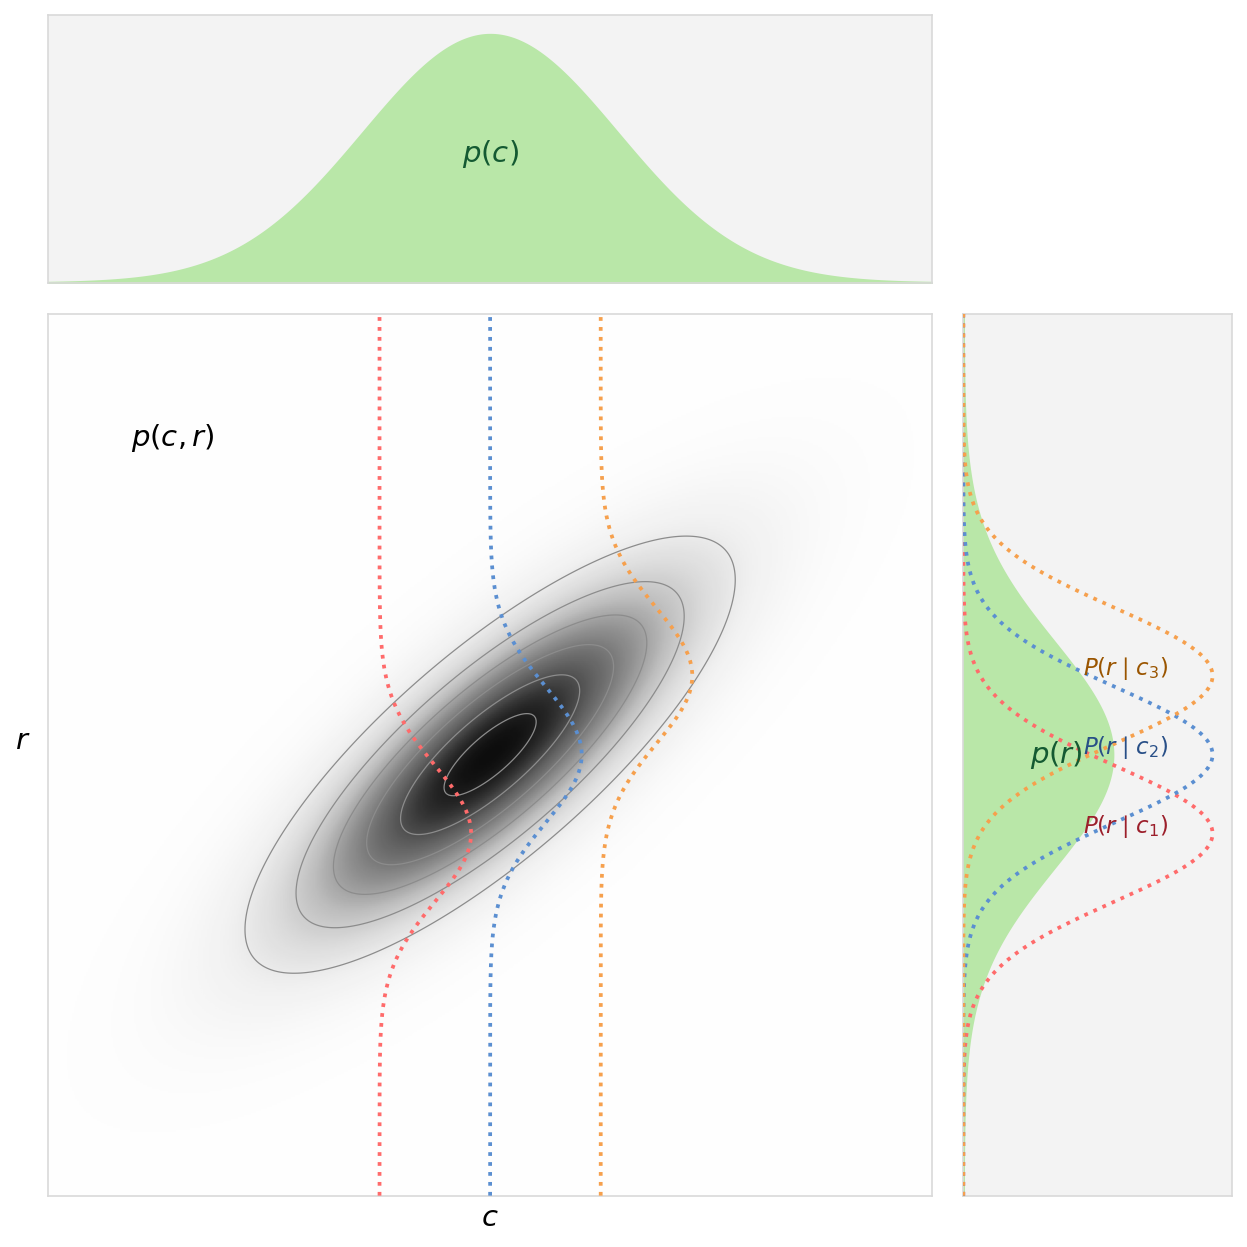

In [31]:
C_MEAN = 0.0
R_MEAN = 0.0
C_SD = 1.15
R_SD = 0.9
RHO = 0.8
C_GRID = np.linspace(-4.0, 4.0, 500)
R_GRID = np.linspace(-3.5, 3.5, 450)
C_MESH, R_MESH = np.meshgrid(C_GRID, R_GRID)
JOINT_DENSITY = bivariate_normal_density(C_MESH, R_MESH, C_MEAN, R_MEAN, C_SD, R_SD, RHO)
MARGINAL_C = normal_pdf(C_GRID, C_MEAN, C_SD)
MARGINAL_R = normal_pdf(R_GRID, R_MEAN, R_SD)
C_CONDITION_LEVELS = [-1.0, 0.0, 1.0]
C_CONDITION_COLORS = ["#ff6b6b", "#5b8fd1", "#f6a04d"]
C_CONDITION_TEXT_COLORS = ["#9c1f2b", "#284f87", "#9a5500"]
R_CONDITION_LEVEL = 0.9

conditional_r_curves = []
for c_value in C_CONDITION_LEVELS:
    conditional_r_mean, conditional_r_sd = conditional_normal_parameters(R_MEAN, C_MEAN, R_SD, C_SD, RHO, c_value)
    conditional_r_curves.append((c_value, conditional_r_mean, normal_pdf(R_GRID, conditional_r_mean, conditional_r_sd)))

conditional_c_mean, conditional_c_sd = conditional_normal_parameters(C_MEAN, R_MEAN, C_SD, R_SD, RHO, R_CONDITION_LEVEL)
conditional_c_density = normal_pdf(C_GRID, conditional_c_mean, conditional_c_sd)

fig = plt.figure(figsize=(8.2, 8.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[4.6, 1.4], height_ratios=[1.4, 4.6], wspace=0.05, hspace=0.05)
top_ax = fig.add_subplot(grid[0, 0])
main_ax = fig.add_subplot(grid[1, 0], sharex=top_ax)
right_ax = fig.add_subplot(grid[1, 1], sharey=main_ax)

top_ax.fill_between(C_GRID, MARGINAL_C, color=CONDITIONAL_MARGINAL_FILL_COLOR, zorder=1)
top_ax.set_xlim(C_GRID.min(), C_GRID.max())
top_ax.set_ylim(0, MARGINAL_C.max() * 1.08)
top_ax.text(
    0.0,
    MARGINAL_C.max() * 0.52,
    r"$p(c)$",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=CONDITIONAL_MARGINAL_LABEL_COLOR,
    zorder=6,
)

main_ax.imshow(
    JOINT_DENSITY,
    extent=[C_GRID.min(), C_GRID.max(), R_GRID.min(), R_GRID.max()],
    origin="lower",
    cmap="Greys",
    aspect="auto",
    alpha=0.95,
)
main_ax.contour(C_GRID, R_GRID, JOINT_DENSITY, levels=6, colors="0.55", linewidths=0.6)
main_ax.text(-3.25, 2.45, r"$p(c, r)$", fontsize=14, fontweight="bold", zorder=6)

for (c_value, _, conditional_r_density), color in zip(conditional_r_curves, C_CONDITION_COLORS):
    scaled_density = 0.72 * C_SD * conditional_r_density / conditional_r_density.max()
    main_ax.plot(c_value + scaled_density, R_GRID, color=color, linestyle=":", linewidth=1.8, zorder=4)

main_ax.set_xlabel(r"$c$", fontsize=14)
main_ax.set_ylabel(r"$r$", fontsize=14, rotation=0, labelpad=12)
main_ax.set_xlim(C_GRID.min(), C_GRID.max())
main_ax.set_ylim(R_GRID.min(), R_GRID.max())
main_ax.set_xticks(C_CONDITION_LEVELS)
main_ax.set_xticklabels([r"$c_1$", r"$c_2$", r"$c_3$"], fontsize=12)
main_ax.tick_params(axis="x", length=0)

right_ax.fill_betweenx(R_GRID, 0, MARGINAL_R, color=CONDITIONAL_MARGINAL_FILL_COLOR, zorder=1)
max_r_density = max([MARGINAL_R.max(), *(curve.max() for _, _, curve in conditional_r_curves)])
for index, ((_, conditional_r_mean, conditional_r_density), color, text_color) in enumerate(
    zip(conditional_r_curves, C_CONDITION_COLORS, C_CONDITION_TEXT_COLORS), start=1
):
    right_ax.plot(conditional_r_density, R_GRID, color=color, linestyle=":", linewidth=1.8, zorder=3)
    right_ax.text(
        max_r_density * 0.48,
        conditional_r_mean + 0.06,
        rf"$P(r \mid c_{index})$",
        color=text_color,
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="center",
        zorder=7,
    )
right_ax.set_xlim(0, max_r_density * 1.08)
right_ax.text(
    MARGINAL_R.max() * 0.62,
    0.0,
    r"$p(r)$",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=CONDITIONAL_MARGINAL_LABEL_COLOR,
    zorder=6,
)

for ax in (top_ax, right_ax):
    ax.set_xticks([])
for ax in (top_ax, main_ax, right_ax):
    ax.set_yticks([])
    ax.set_facecolor("#f3f3f3")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("0.85")

plt.show()


This first figure emphasizes three examples of $p(r \mid c)$. The next figure switches
the conditioning direction and isolates a single $p(c \mid r)$ slice.


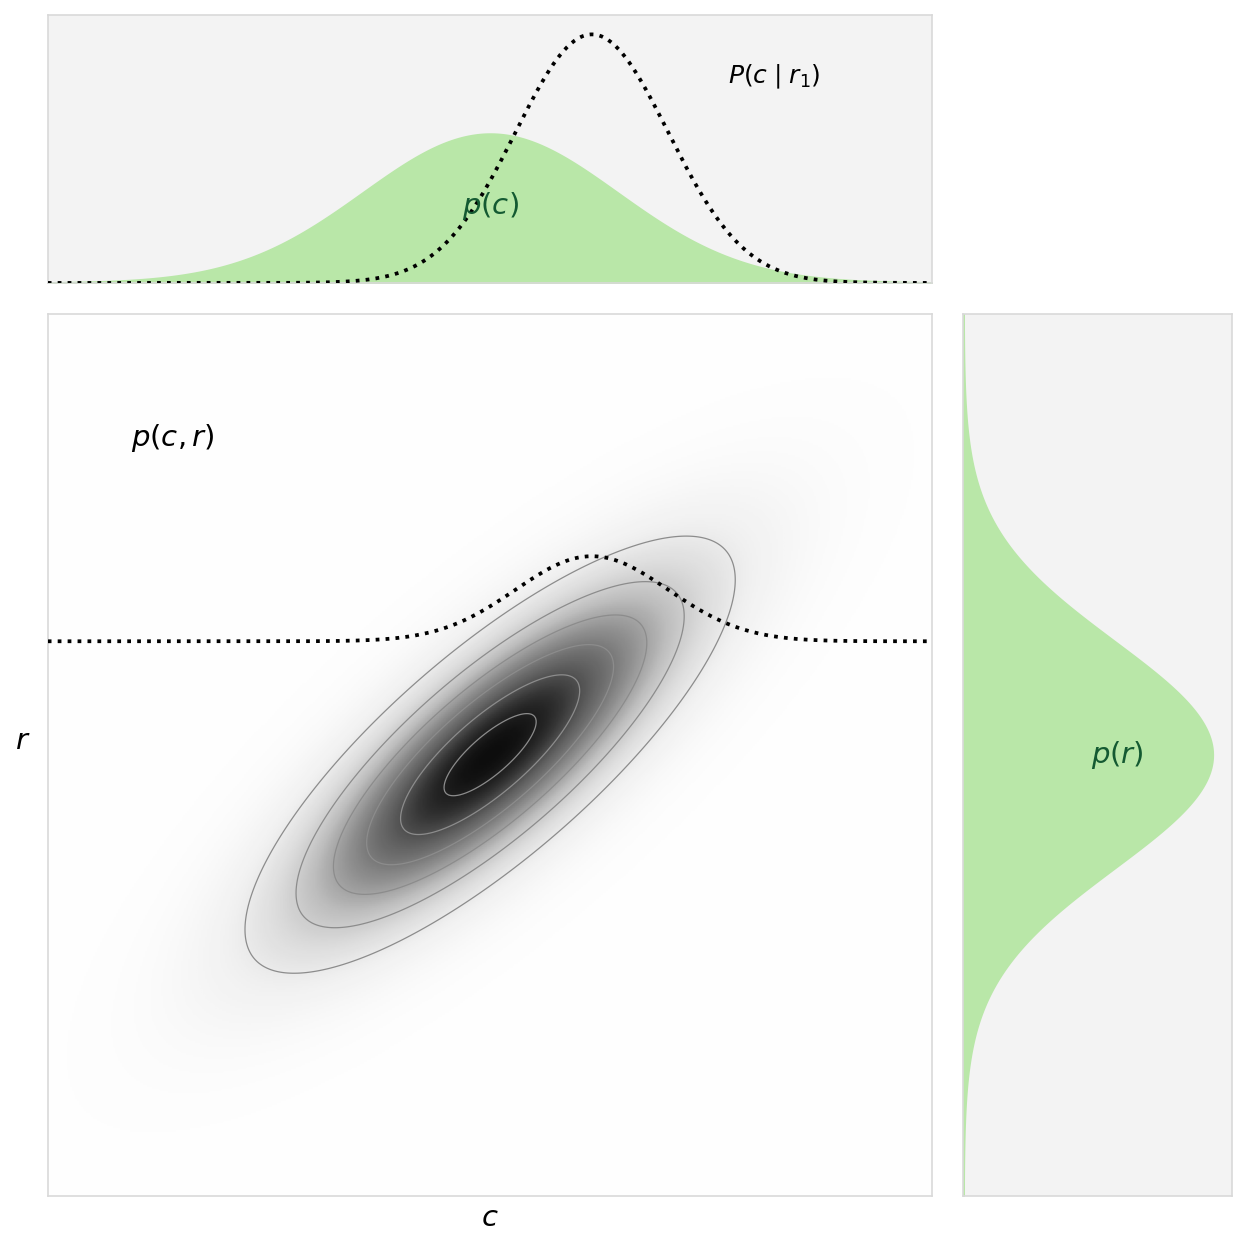

In [32]:
fig = plt.figure(figsize=(8.2, 8.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=[4.6, 1.4], height_ratios=[1.4, 4.6], wspace=0.05, hspace=0.05)
top_ax = fig.add_subplot(grid[0, 0])
main_ax = fig.add_subplot(grid[1, 0], sharex=top_ax)
right_ax = fig.add_subplot(grid[1, 1], sharey=main_ax)

top_ax.fill_between(C_GRID, MARGINAL_C, color=CONDITIONAL_MARGINAL_FILL_COLOR, zorder=1)
top_ax.plot(C_GRID, conditional_c_density, color="black", linestyle=":", linewidth=1.8, zorder=3)
top_ax.set_xlim(C_GRID.min(), C_GRID.max())
top_ax.set_ylim(0, max(MARGINAL_C.max(), conditional_c_density.max()) * 1.08)
top_ax.text(
    0.0,
    MARGINAL_C.max() * 0.52,
    r"$p(c)$",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=CONDITIONAL_MARGINAL_LABEL_COLOR,
    zorder=6,
)

main_ax.imshow(
    JOINT_DENSITY,
    extent=[C_GRID.min(), C_GRID.max(), R_GRID.min(), R_GRID.max()],
    origin="lower",
    cmap="Greys",
    aspect="auto",
    alpha=0.95,
)
main_ax.contour(C_GRID, R_GRID, JOINT_DENSITY, levels=6, colors="0.55", linewidths=0.6)
main_ax.text(-3.25, 2.45, r"$p(c, r)$", fontsize=14, fontweight="bold", zorder=6)
scaled_density = 0.75 * R_SD * conditional_c_density / conditional_c_density.max()
main_ax.plot(C_GRID, R_CONDITION_LEVEL + scaled_density, color="black", linestyle=":", linewidth=1.8, zorder=4)
main_ax.set_xlabel(r"$c$", fontsize=14)
main_ax.set_ylabel(r"$r$", fontsize=14, rotation=0, labelpad=12)
main_ax.set_xlim(C_GRID.min(), C_GRID.max())
main_ax.set_ylim(R_GRID.min(), R_GRID.max())
main_ax.set_yticks([R_CONDITION_LEVEL])
main_ax.set_yticklabels([r"$r_1$"], fontsize=12)
main_ax.tick_params(axis="y", length=0)

right_ax.fill_betweenx(R_GRID, 0, MARGINAL_R, color=CONDITIONAL_MARGINAL_FILL_COLOR, zorder=1)
right_ax.set_xlim(0, MARGINAL_R.max() * 1.08)
right_ax.text(
    MARGINAL_R.max() * 0.62,
    0.0,
    r"$p(r)$",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=CONDITIONAL_MARGINAL_LABEL_COLOR,
    zorder=6,
)
top_ax.text(
    2.15,
    conditional_c_density.max() * 0.83,
    r"$P(c \mid r_1)$",
    color="black",
    fontsize=12,
    fontweight="bold",
    ha="left",
    va="center",
    zorder=7,
)

for ax in (top_ax, main_ax, right_ax):
    ax.set_xticks([])
    ax.set_facecolor("#f3f3f3")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("0.85")

top_ax.set_yticks([])
right_ax.set_yticks([])

plt.show()


<a id="section-23"></a>
## 2.3 Bayes rule
### Updating beliefs with data

Slides 15-19 introduce Bayes rule and name its components. The notebook picks up again
when the lecture moves from formulas to executable coin-flip examples.


<a id="section-24"></a>
## 2.4 Likelihood
### Probability of the data as a function of the parameter

Slides 20-28 move from the model diagram to the likelihood. The cells below reproduce
the binomial examples used to show how the data shape the likelihood and, through Bayes
rule, the posterior.


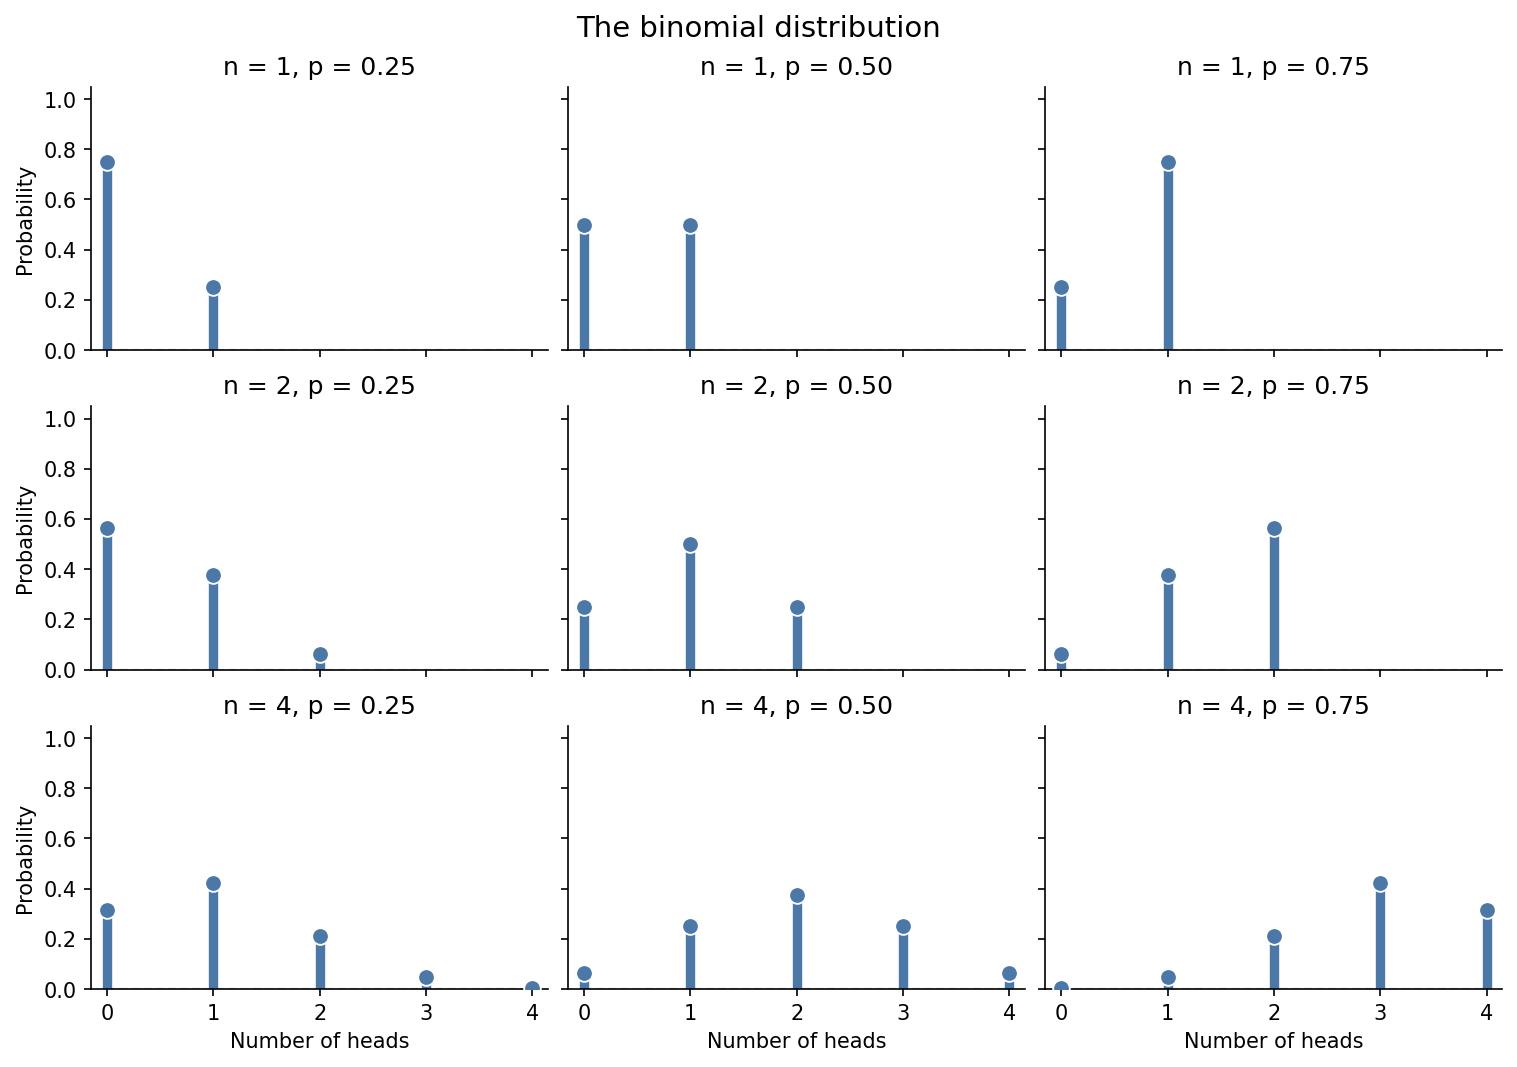

In [33]:
n_params = [1, 2, 4]
p_params = [0.25, 0.50, 0.75]
binomial_support = np.arange(0, 5)

fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharex=True, sharey=True, constrained_layout=True)

for row, n in enumerate(n_params):
    x_values = np.arange(0, n + 1)
    for col, p in enumerate(p_params):
        ax = axes[row, col]
        pmf = np.array([comb(n, k) * p**k * (1 - p) ** (n - k) for k in x_values])
        ax.hlines(0, binomial_support.min(), binomial_support.max(), color="0.82", linestyle="--", linewidth=1.1, zorder=1)
        ax.vlines(x_values, 0, pmf, color=LIKELIHOOD_COMPONENT_COLOR, lw=4.5, zorder=2)
        ax.scatter(
            x_values,
            pmf,
            color=LIKELIHOOD_COMPONENT_COLOR,
            s=64,
            edgecolors="white",
            linewidths=0.9,
            zorder=3,
        )
        ax.set_xlim(-0.15, 4.15)
        ax.set_xticks(binomial_support)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"n = {n}, p = {p:.2f}")
        if row == len(n_params) - 1:
            ax.set_xlabel("Number of heads")
        if col == 0:
            ax.set_ylabel("Probability")

fig.suptitle("The binomial distribution", fontsize=14)
plt.show()


The next figures are intentionally emitted one axis at a time so they can be combined
on slides in the same way the current deck assembles them.


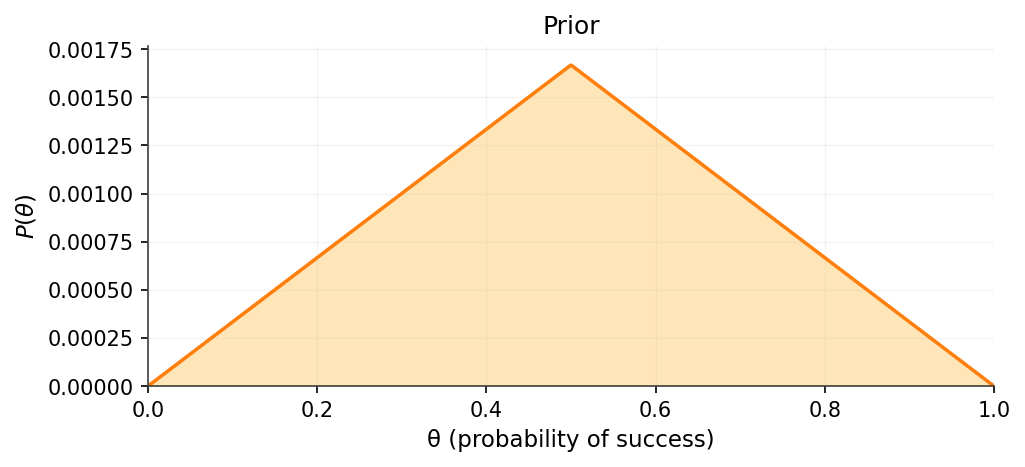

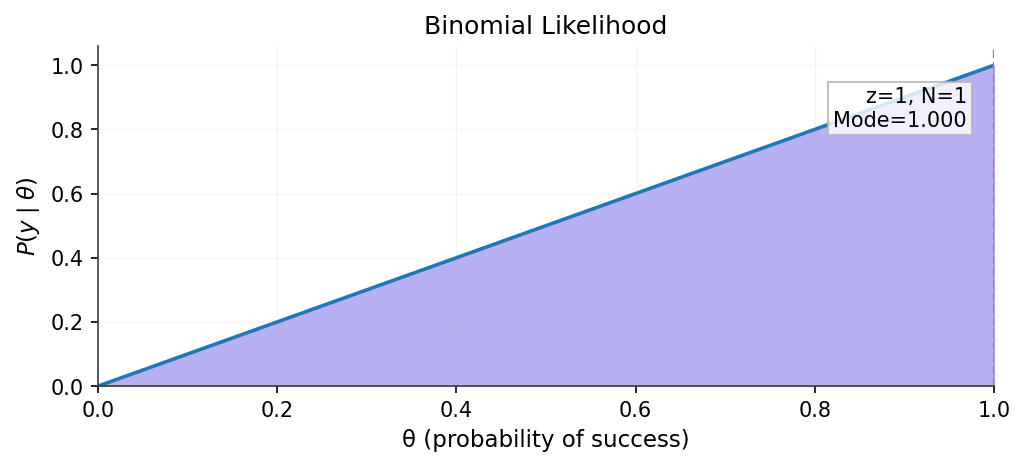

In [34]:
slide_prior = triangular_prior_density(THETA_GRID)
plot_slide_distribution(
    THETA_GRID,
    slide_prior,
    title="Prior",
    ylabel=r"$P(\theta)$",
    line_color=SLIDE_PRIOR_LINE_COLOR,
    fill_color=SLIDE_PRIOR_FILL_COLOR,
    display_as_mass=True,
)

simple_likelihood = binomial_likelihood(THETA_GRID, 1, 1)
plot_slide_distribution(
    THETA_GRID,
    simple_likelihood,
    title="Binomial Likelihood",
    ylabel=r"$P(y \mid \theta)$",
    line_color=SLIDE_LIKELIHOOD_LINE_COLOR,
    fill_color=SLIDE_LIKELIHOOD_FILL_COLOR,
    box_lines=["z=1, N=1"],
    show_mode=True,
)


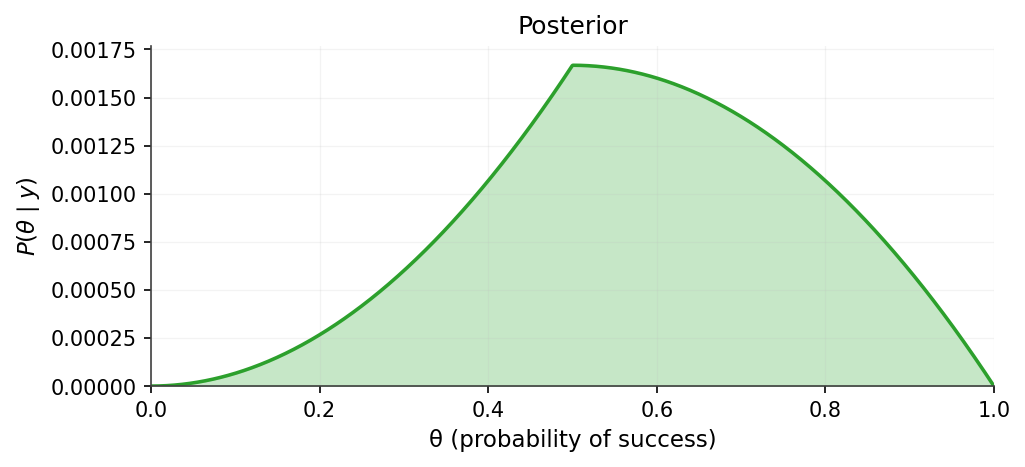

In [35]:
simple_posterior = posterior_from_curve(THETA_GRID, slide_prior, 1, 1)
plot_slide_distribution(
    THETA_GRID,
    simple_posterior,
    title="Posterior",
    ylabel=r"$P(\theta \mid y)$",
    line_color=SLIDE_POSTERIOR_LINE_COLOR,
    fill_color=SLIDE_POSTERIOR_FILL_COLOR,
    display_as_mass=True,
)


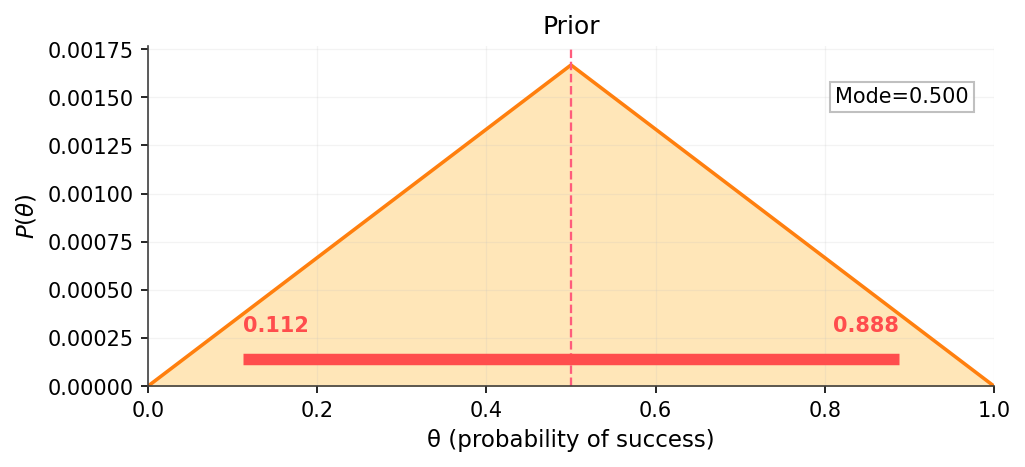

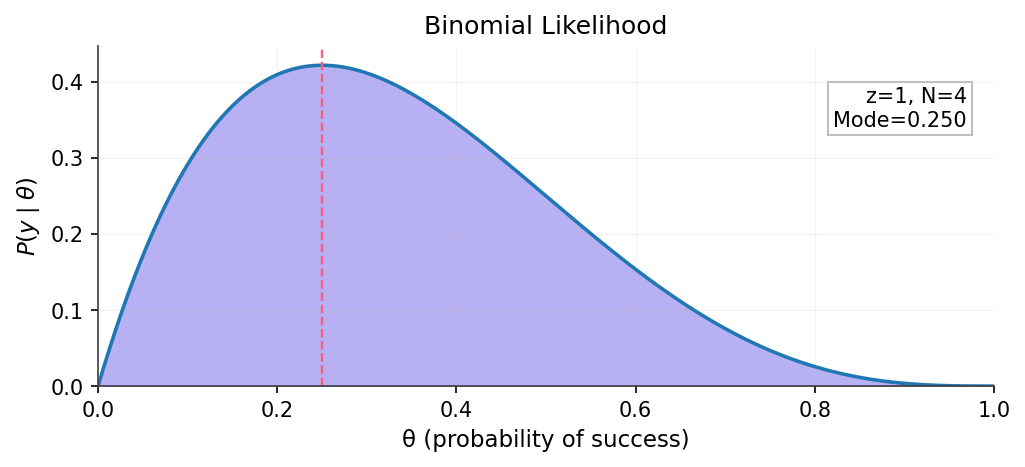

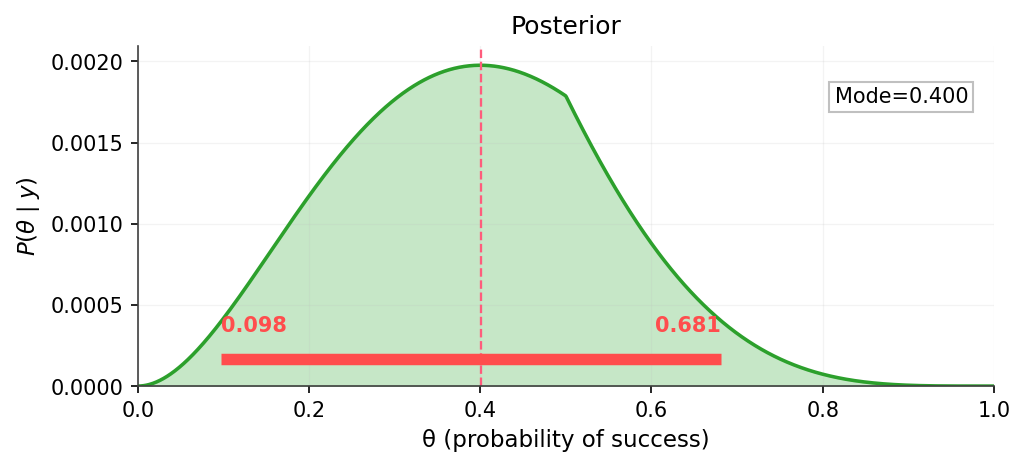

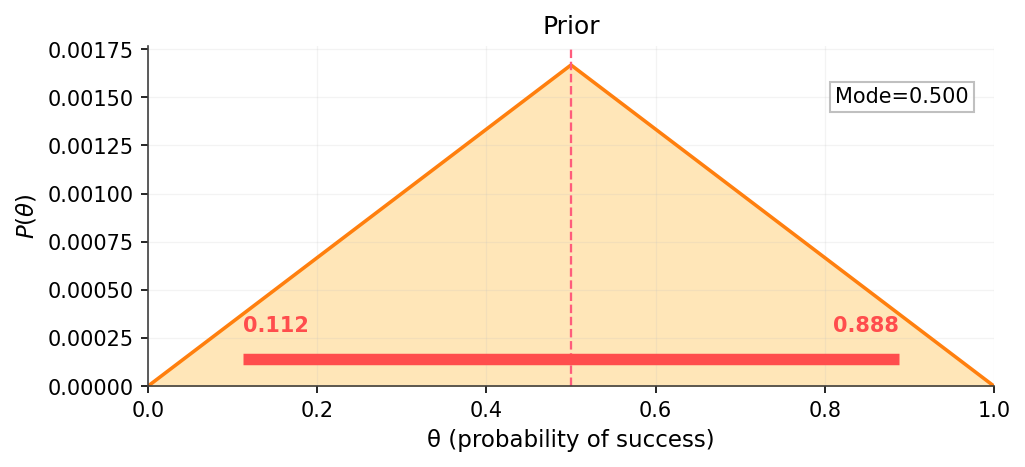

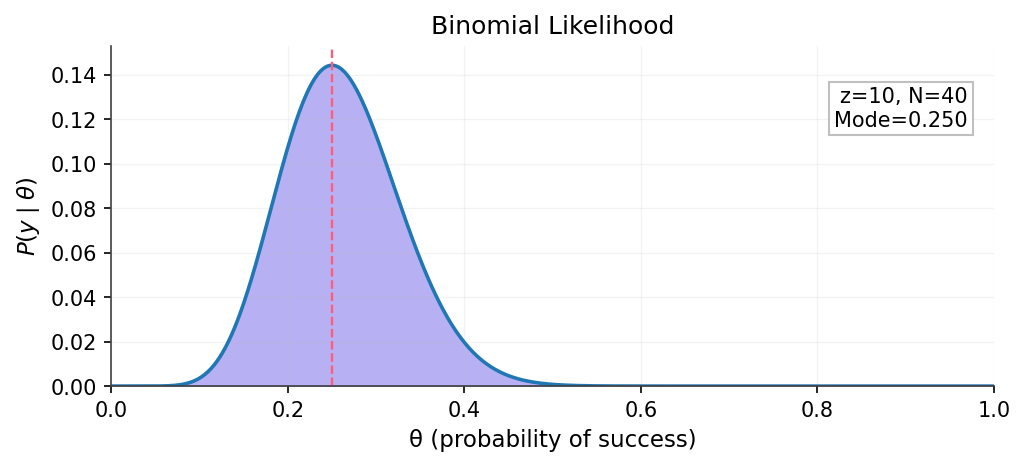

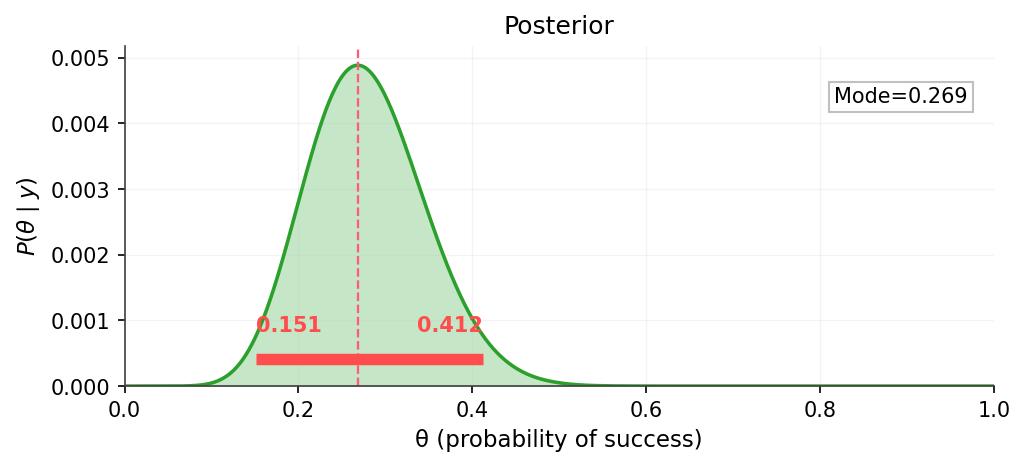

In [36]:
annotated_cases = [(1, 4), (10, 40)]
for z, n in annotated_cases:
    plot_slide_distribution(
        THETA_GRID,
        slide_prior,
        title="Prior",
        ylabel=r"$P(\theta)$",
        line_color=SLIDE_PRIOR_LINE_COLOR,
        fill_color=SLIDE_PRIOR_FILL_COLOR,
        show_mode=True,
        show_interval=True,
        display_as_mass=True,
    )
    likelihood = binomial_likelihood(THETA_GRID, z, n)
    posterior = posterior_from_curve(THETA_GRID, slide_prior, z, n)
    plot_slide_distribution(
        THETA_GRID,
        likelihood,
        title="Binomial Likelihood",
        ylabel=r"$P(y \mid \theta)$",
        line_color=SLIDE_LIKELIHOOD_LINE_COLOR,
        fill_color=SLIDE_LIKELIHOOD_FILL_COLOR,
        box_lines=[f"z={z}, N={n}"],
        show_mode=True,
    )
    plot_slide_distribution(
        THETA_GRID,
        posterior,
        title="Posterior",
        ylabel=r"$P(\theta \mid y)$",
        line_color=SLIDE_POSTERIOR_LINE_COLOR,
        fill_color=SLIDE_POSTERIOR_FILL_COLOR,
        show_mode=True,
        show_interval=True,
        display_as_mass=True,
    )


<a id="section-25"></a>
## 2.5 Grid calculation
### Computing the posterior on a full grid

Slides 32-35 show the computational recipe directly:
`prior * likelihood`, then divide by the total area to normalize.

The four panels below follow that exact sequence for the example `z=1, N=4`.


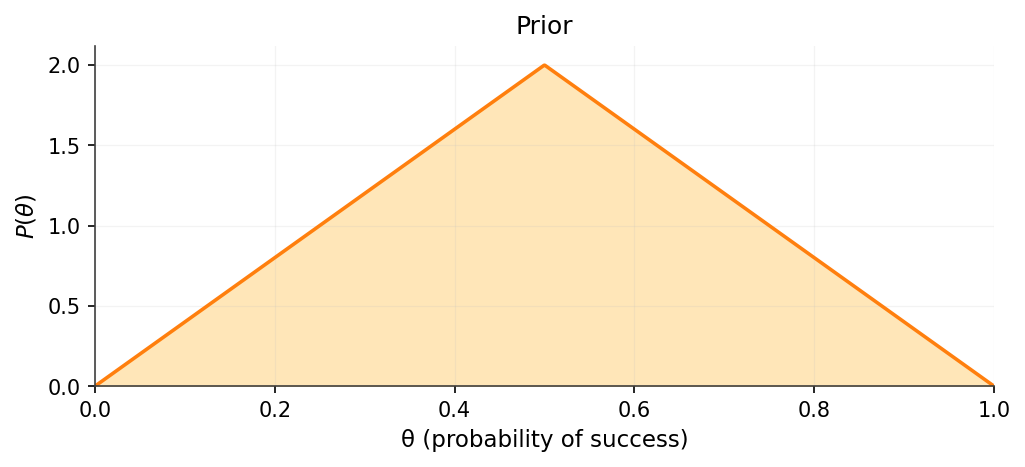

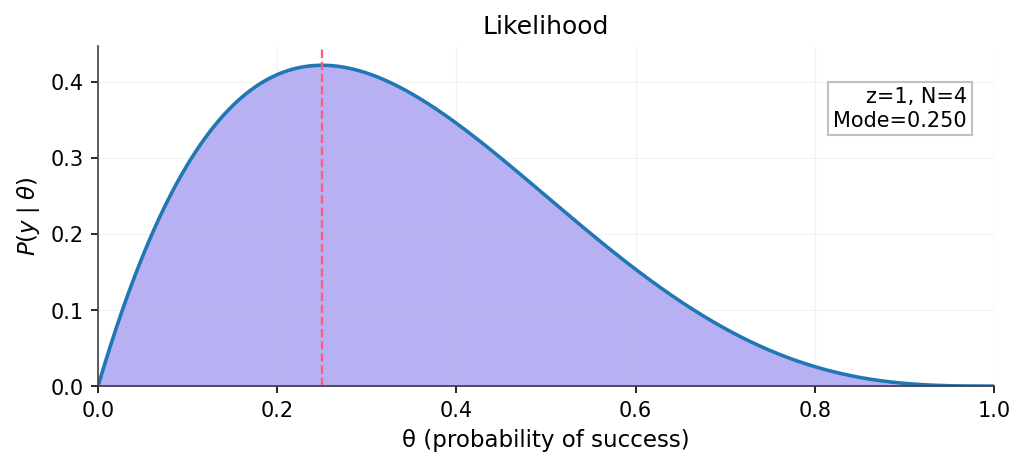

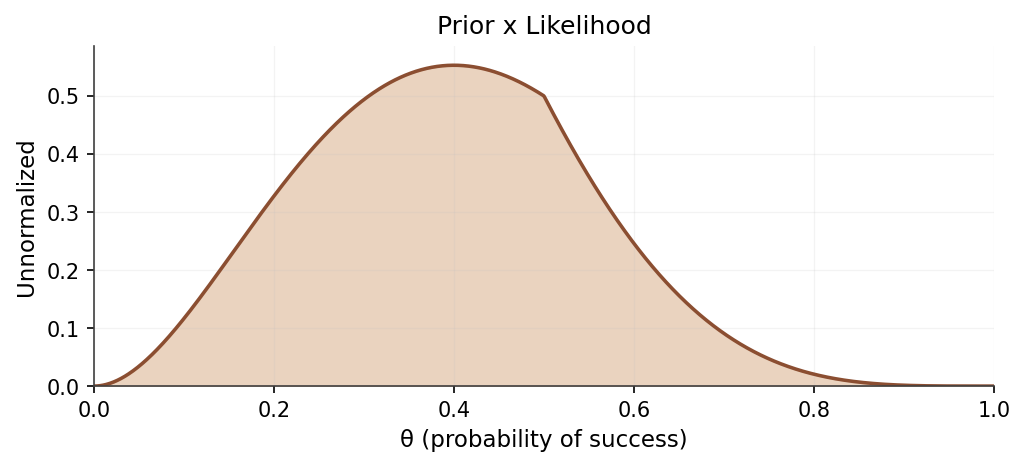

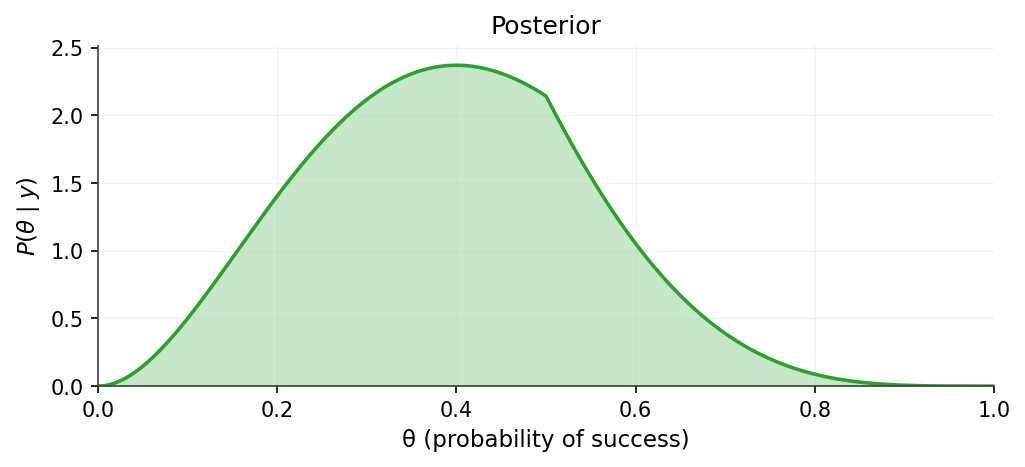

In [37]:
grid_z = 1
grid_n = 4
grid_prior = triangular_prior_density(THETA_GRID)
grid_likelihood = binomial_likelihood(THETA_GRID, grid_z, grid_n)
grid_product = grid_prior * grid_likelihood
grid_area = np.trapezoid(grid_product, THETA_GRID)
grid_posterior = grid_product / grid_area

plot_slide_distribution(
    THETA_GRID,
    grid_prior,
    title="Prior",
    ylabel=r"$P(\theta)$",
    line_color=SLIDE_PRIOR_LINE_COLOR,
    fill_color=SLIDE_PRIOR_FILL_COLOR,
)

plot_slide_distribution(
    THETA_GRID,
    grid_likelihood,
    title="Likelihood",
    ylabel=r"$P(y \mid \theta)$",
    line_color=SLIDE_LIKELIHOOD_LINE_COLOR,
    fill_color=SLIDE_LIKELIHOOD_FILL_COLOR,
    box_lines=[f"z={grid_z}, N={grid_n}"],
    show_mode=True,
)

plot_slide_distribution(
    THETA_GRID,
    grid_product,
    title="Prior x Likelihood",
    ylabel="Unnormalized",
    line_color="#8b4e31",
    fill_color="#d9b08c",
)

plot_slide_distribution(
    THETA_GRID,
    grid_posterior,
    title="Posterior",
    ylabel=r"$P(\theta \mid y)$",
    line_color=SLIDE_POSTERIOR_LINE_COLOR,
    fill_color=SLIDE_POSTERIOR_FILL_COLOR,
)


In [38]:
print(f"z={grid_z}, N={grid_n}")
print(f"Normalization constant (area under prior x likelihood): {grid_area:.6f}")
print(f"Area under posterior after normalization: {np.trapezoid(grid_posterior, THETA_GRID):.6f}")


z=1, N=4
Normalization constant (area under prior x likelihood): 0.233333
Area under posterior after normalization: 1.000000


<a id="section-26"></a>
## 2.6 Prior
### Probability distributions before data are observed

Slides 36-39 frame the prior as a model assumption and show how posterior conclusions
can change when the same data are paired with different prior beliefs.


To compare prior choices directly, we reuse the broad triangular prior and the
`z=1, N=4` likelihood from section `2.4` as the first column. The cells below add the
missing figures for a narrower triangular prior on `[0.3, 0.7]`, first with the same
`z=1, N=4` likelihood and then with the sharper `z=10, N=40` likelihood.


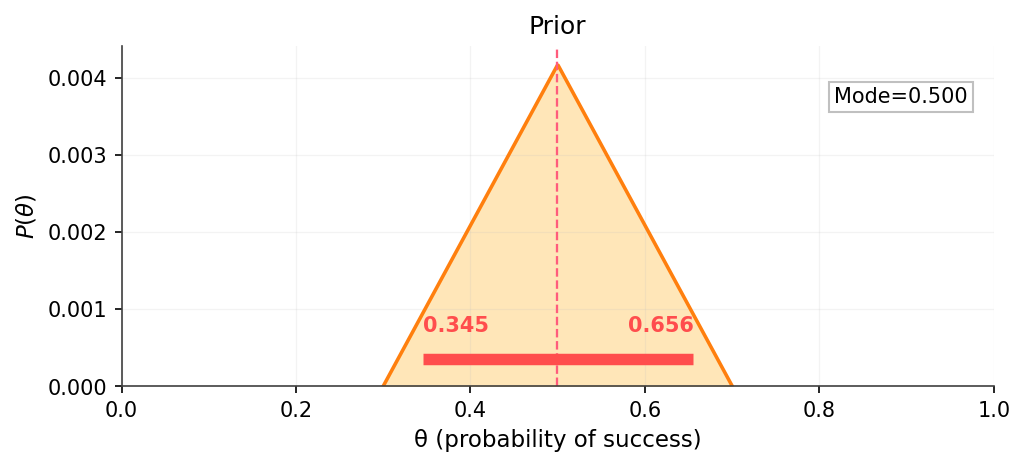

In [39]:
narrow_triangular_prior = triangular_prior_density(THETA_GRID, lower=0.3, mode=0.5, upper=0.7)
plot_slide_distribution(
    THETA_GRID,
    narrow_triangular_prior,
    title="Prior",
    ylabel=r"$P(\theta)$",
    line_color=SLIDE_PRIOR_LINE_COLOR,
    fill_color=SLIDE_PRIOR_FILL_COLOR,
    show_mode=True,
    show_interval=True,
    display_as_mass=True,
    trim_zero_support=True,
)


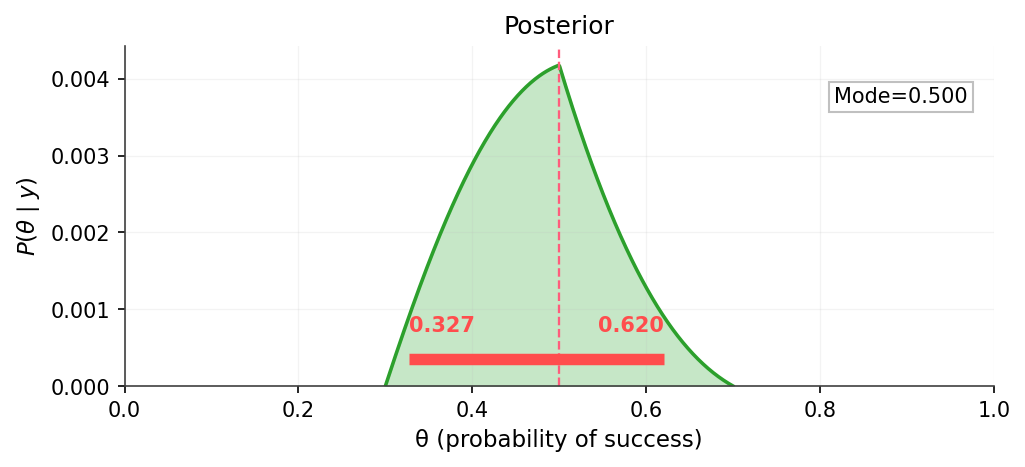

In [40]:
narrow_posterior_small_sample = posterior_from_curve(THETA_GRID, narrow_triangular_prior, 1, 4)
plot_slide_distribution(
    THETA_GRID,
    narrow_posterior_small_sample,
    title="Posterior",
    ylabel=r"$P(\theta \mid y)$",
    line_color=SLIDE_POSTERIOR_LINE_COLOR,
    fill_color=SLIDE_POSTERIOR_FILL_COLOR,
    show_mode=True,
    show_interval=True,
    display_as_mass=True,
    trim_zero_support=True,
)


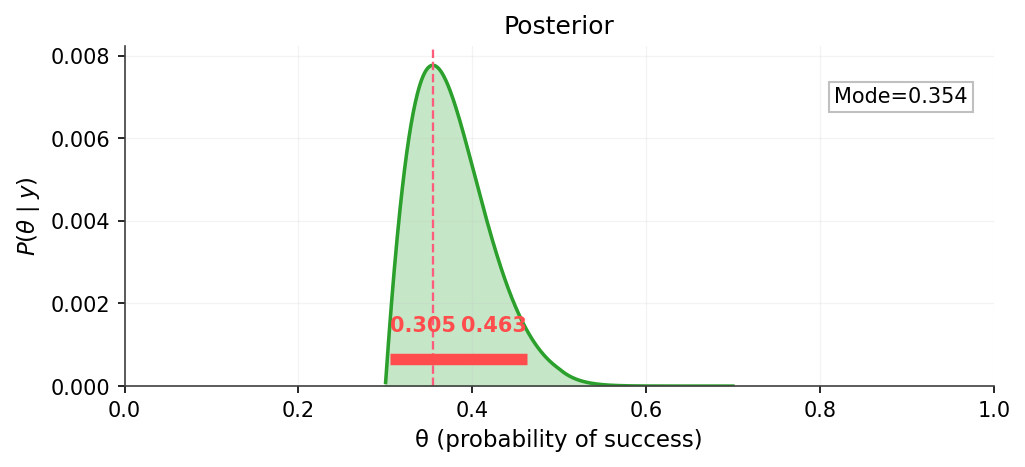

In [41]:
narrow_posterior_large_sample = posterior_from_curve(THETA_GRID, narrow_triangular_prior, 10, 40)
plot_slide_distribution(
    THETA_GRID,
    narrow_posterior_large_sample,
    title="Posterior",
    ylabel=r"$P(\theta \mid y)$",
    line_color=SLIDE_POSTERIOR_LINE_COLOR,
    fill_color=SLIDE_POSTERIOR_FILL_COLOR,
    show_mode=True,
    show_interval=True,
    display_as_mass=True,
    trim_zero_support=True,
)


<a id="section-27"></a>
## 2.7 Beta distribution
### A flexible prior family for probabilities

Slides 40-44 motivate the Beta distribution as a prior for a probability parameter:
it lives on $[0, 1]$, it can take many shapes, and it stays in the same family after
updating with binomial data.


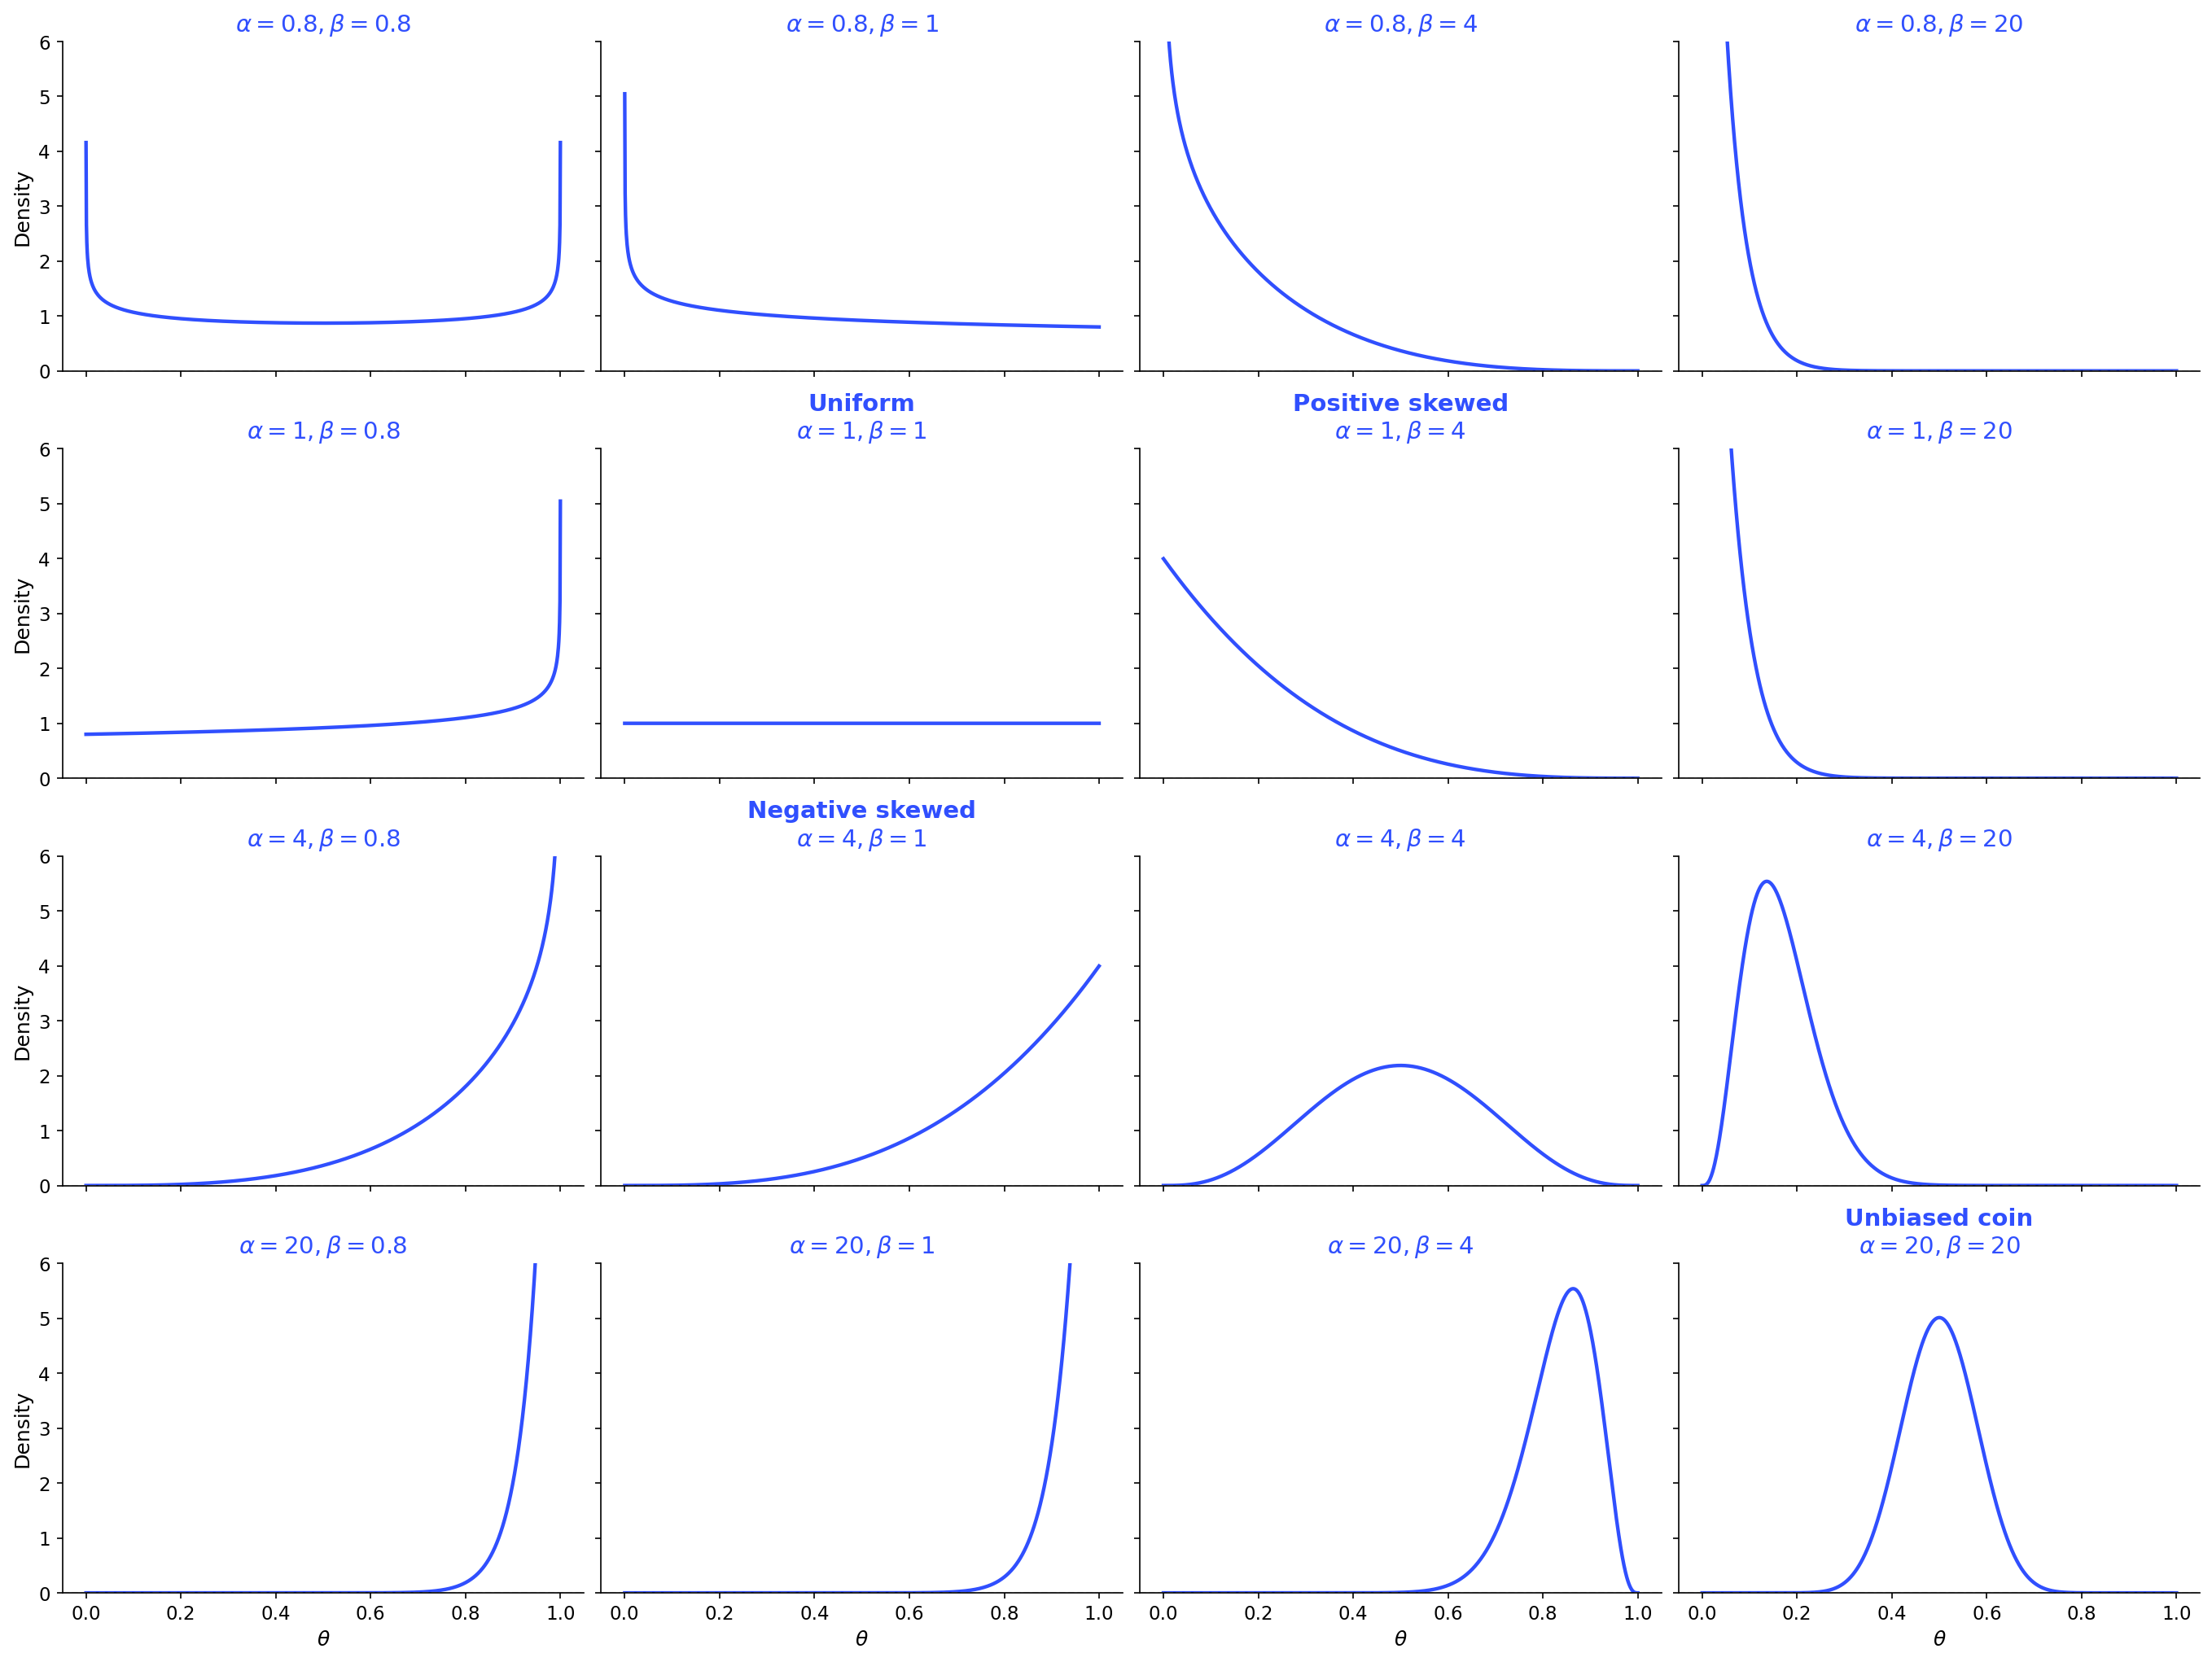

In [42]:
highlight_lookup = {(alpha, beta): label for label, alpha, beta in BETA_HIGHLIGHT_SPECS}

fig, axes = plt.subplots(4, 4, figsize=BETA_MATRIX_FIGSIZE, sharex=True, sharey=True, constrained_layout=True)

for row, alpha in enumerate(BETA_MATRIX_PARAMS):
    for col, beta in enumerate(BETA_MATRIX_PARAMS):
        ax = axes[row, col]
        density = beta_density(THETA_GRID, alpha, beta)
        title = beta_param_text(alpha, beta)
        if (alpha, beta) in highlight_lookup:
            highlight_label = highlight_lookup[(alpha, beta)]
            title = f"{highlight_label}\n{title}"
        ax.plot(THETA_GRID, density, color=BETA_MATRIX_COLOR, linewidth=2.1)
        ax.axhline(0, color="0.82", linestyle="--", linewidth=1.0)
        ax.set_title(title, color=BETA_MATRIX_COLOR, fontsize=14, fontweight="bold", pad=6)
        ax.set_ylim(0, BETA_MATRIX_YMAX)
        if row == len(BETA_MATRIX_PARAMS) - 1:
            ax.set_xlabel(r"$\theta$", fontsize=12)
        if col == 0:
            ax.set_ylabel("Density", fontsize=12)
        ax.tick_params(labelsize=11)

beta_panel_figsize, beta_panel_axes_rect = beta_panel_geometry(fig, axes[1, 1])

plt.show()


The highlighted priors below use the same aspect ratio as the slide figures, so they
can be overlaid or reused independently.


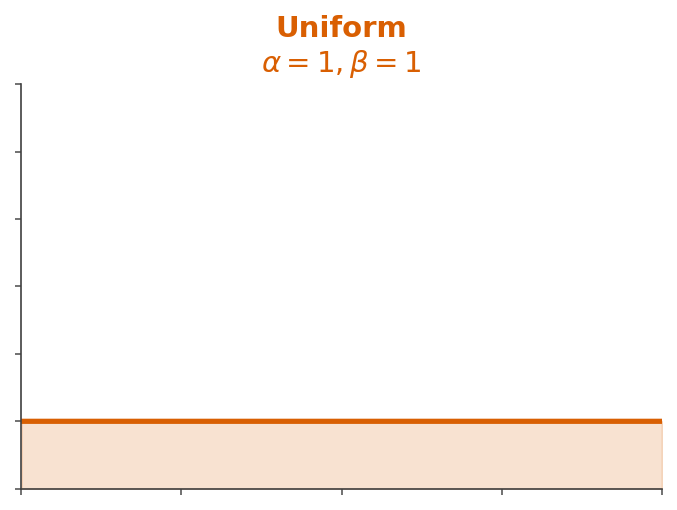

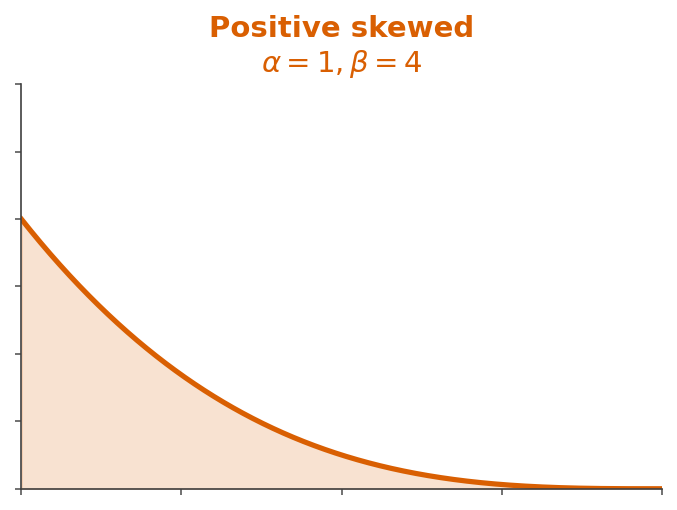

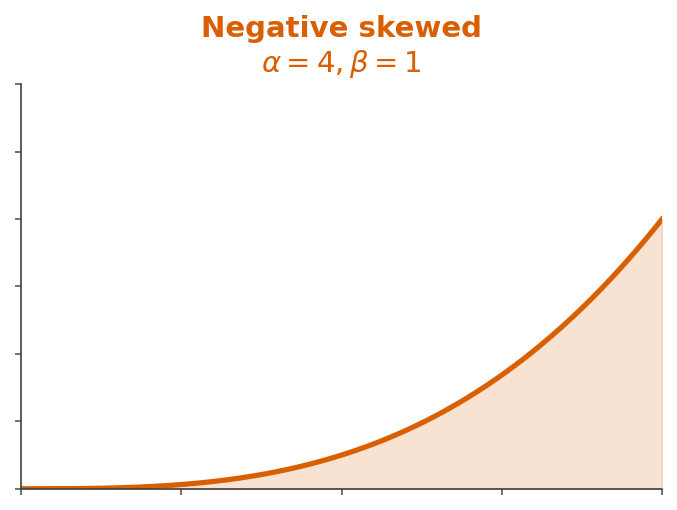

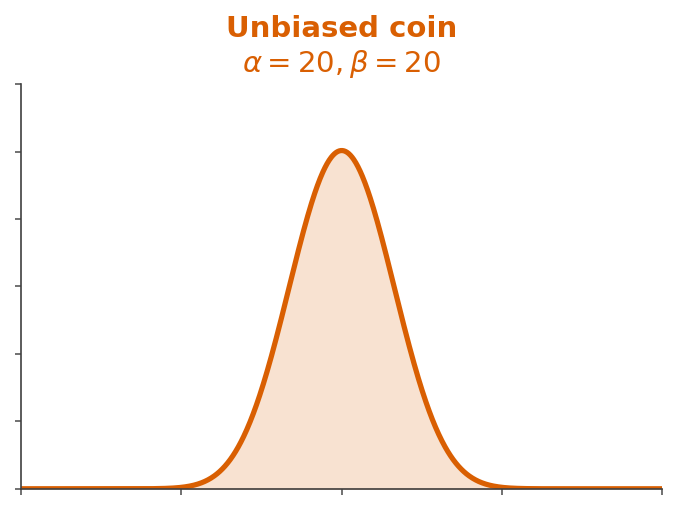

In [43]:
for label, alpha, beta in BETA_HIGHLIGHT_SPECS:
    density = beta_density(THETA_GRID, alpha, beta)
    fig = plt.figure(figsize=beta_panel_figsize)
    ax = fig.add_axes(beta_panel_axes_rect)
    ax.plot(THETA_GRID, density, color=BETA_OVERLAY_COLOR, linewidth=2.5)
    ax.fill_between(THETA_GRID, density, color=BETA_OVERLAY_COLOR, alpha=0.18)
    ax.set_title(f"{label}\n{beta_param_text(alpha, beta)}", color=BETA_OVERLAY_COLOR, fontsize=14, fontweight="bold", pad=6)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_ylim(0, BETA_MATRIX_YMAX)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=3, width=0.8, colors="0.35")
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")
    plt.show()


<a id="section-28"></a>
## 2.8 Conjugate priors
### Beta-binomial updating and pseudo-count intuition

Slides 45-52 derive the Beta-binomial update analytically. The main computational
takeaway is:

$$
\text{Beta}(\alpha, \beta) + z \text{ heads in } N \text{ flips}
\longrightarrow
\text{Beta}(\alpha + z, \beta + N - z)
$$

The cells below verify that update numerically and then visualize the common
pseudo-count intuition. In the bar chart, we use the convention
$\\alpha - 1$ prior heads and $\\beta - 1$ prior tails, so `Beta(1, 1)` corresponds
to starting with no prior coin flips.


In [44]:
conjugate_alpha, conjugate_beta = 4, 6
conjugate_z, conjugate_n = 3, 5
posterior_alpha, posterior_beta = posterior_parameters(conjugate_alpha, conjugate_beta, conjugate_z, conjugate_n)

numeric_posterior = posterior_from_product(THETA_GRID, conjugate_alpha, conjugate_beta, conjugate_z, conjugate_n)
analytic_posterior = normalize_density(
    THETA_GRID,
    beta_density(THETA_GRID, posterior_alpha, posterior_beta),
)
max_difference = np.max(np.abs(numeric_posterior - analytic_posterior))

print(f"Prior: Beta({conjugate_alpha}, {conjugate_beta})")
print(f"Observed data: {conjugate_z} heads in {conjugate_n} flips")
print(f"Posterior: Beta({posterior_alpha}, {posterior_beta})")
print(f"Maximum absolute difference between numeric and analytic posterior: {max_difference:.6f}")


Prior: Beta(4, 6)
Observed data: 3 heads in 5 flips
Posterior: Beta(7, 8)
Maximum absolute difference between numeric and analytic posterior: 0.000000


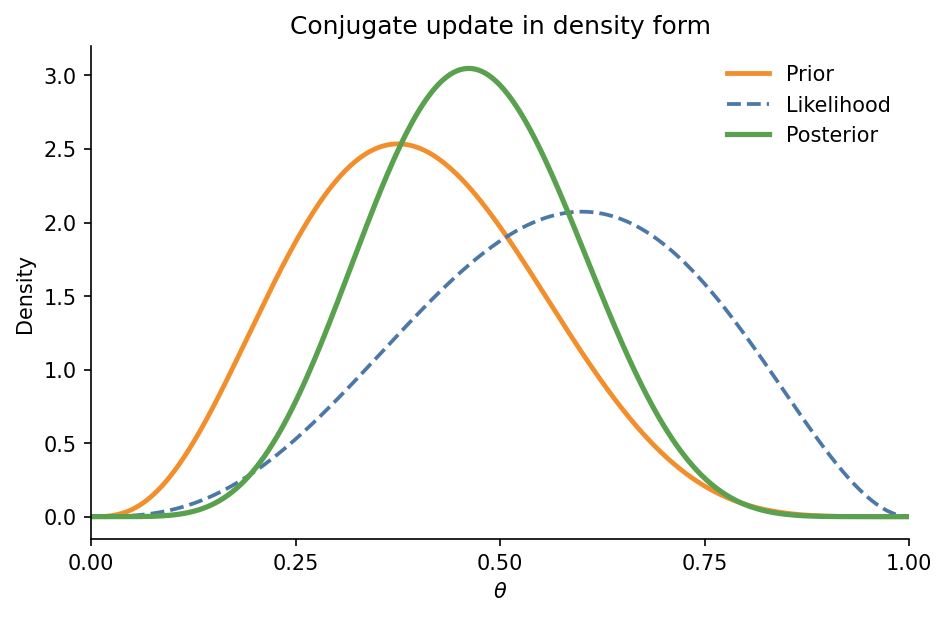

In [45]:
prior_density = beta_density(THETA_GRID, conjugate_alpha, conjugate_beta)
posterior_density_curve = beta_density(THETA_GRID, posterior_alpha, posterior_beta)
likelihood_density = normalized_likelihood(THETA_GRID, conjugate_z, conjugate_n)

stage_labels = ["Prior intuition", "Observed data", "Posterior intuition"]
heads_counts = [conjugate_alpha - 1, conjugate_z, posterior_alpha - 1]
tails_counts = [conjugate_beta - 1, conjugate_n - conjugate_z, posterior_beta - 1]

fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)

ax.plot(THETA_GRID, prior_density, color=PRIOR_COMPONENT_COLOR, linewidth=2.3, label="Prior")
ax.plot(
    THETA_GRID,
    likelihood_density,
    color=LIKELIHOOD_COMPONENT_COLOR,
    linestyle="--",
    linewidth=1.8,
    label="Likelihood",
)
ax.plot(THETA_GRID, posterior_density_curve, color=POSTERIOR_COMPONENT_COLOR, linewidth=2.5, label="Posterior")
ax.set_title("Conjugate update in density form")
format_theta_axis(ax)
ax.legend(frameon=False)

plt.show()


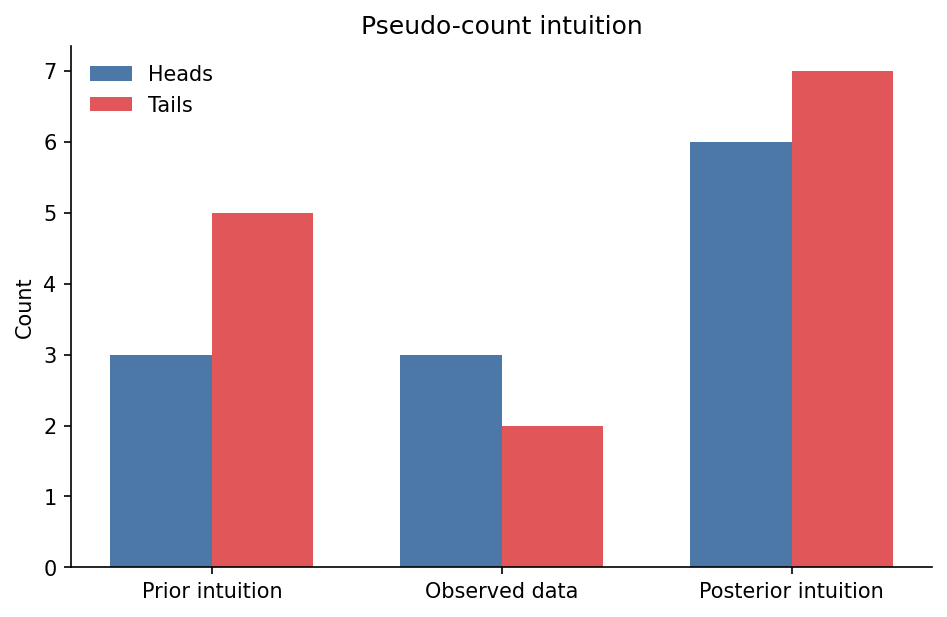

In [46]:
x_positions = np.arange(len(stage_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)

ax.bar(x_positions - bar_width / 2, heads_counts, width=bar_width, color="#4c78a8", label="Heads")
ax.bar(x_positions + bar_width / 2, tails_counts, width=bar_width, color="#e15759", label="Tails")
ax.set_xticks(x_positions)
ax.set_xticklabels(stage_labels)
ax.set_ylabel("Count")
ax.set_title("Pseudo-count intuition")
ax.legend(frameon=False)

plt.show()


<a id="section-29"></a>
## 2.9 Posterior distribution
### Repeated updating for coin-flip data

Slides 53-61 apply the Beta-binomial update repeatedly to the same coin-flip problem.
The lecture compares the same three priors and asks how quickly the posteriors begin
to agree as more data arrive.


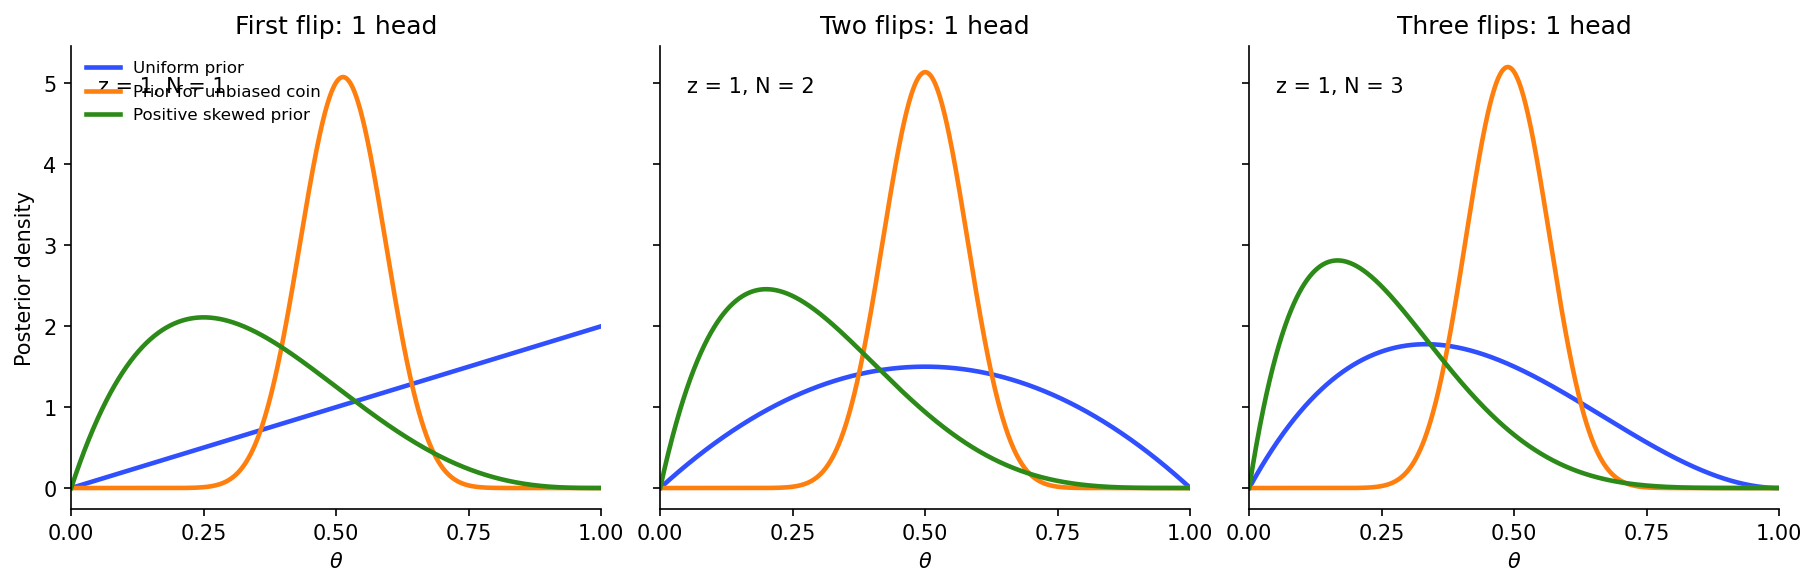

In [47]:
early_update_cases = [
    (1, 1, "First flip: 1 head"),
    (1, 2, "Two flips: 1 head"),
    (1, 3, "Three flips: 1 head"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True)

for ax, (z, n, title) in zip(axes, early_update_cases):
    for label, alpha, beta, color in PRIOR_SPECS:
        posterior = posterior_density(THETA_GRID, alpha, beta, z, n)
        ax.plot(THETA_GRID, posterior, color=color, linewidth=2.2, label=label)

    ax.set_title(title)
    format_theta_axis(ax, ylabel="Posterior density" if ax is axes[0] else None)
    ax.text(0.05, 0.90, case_summary(z, n), transform=ax.transAxes)

axes[0].legend(frameon=False, fontsize=8)
plt.show()


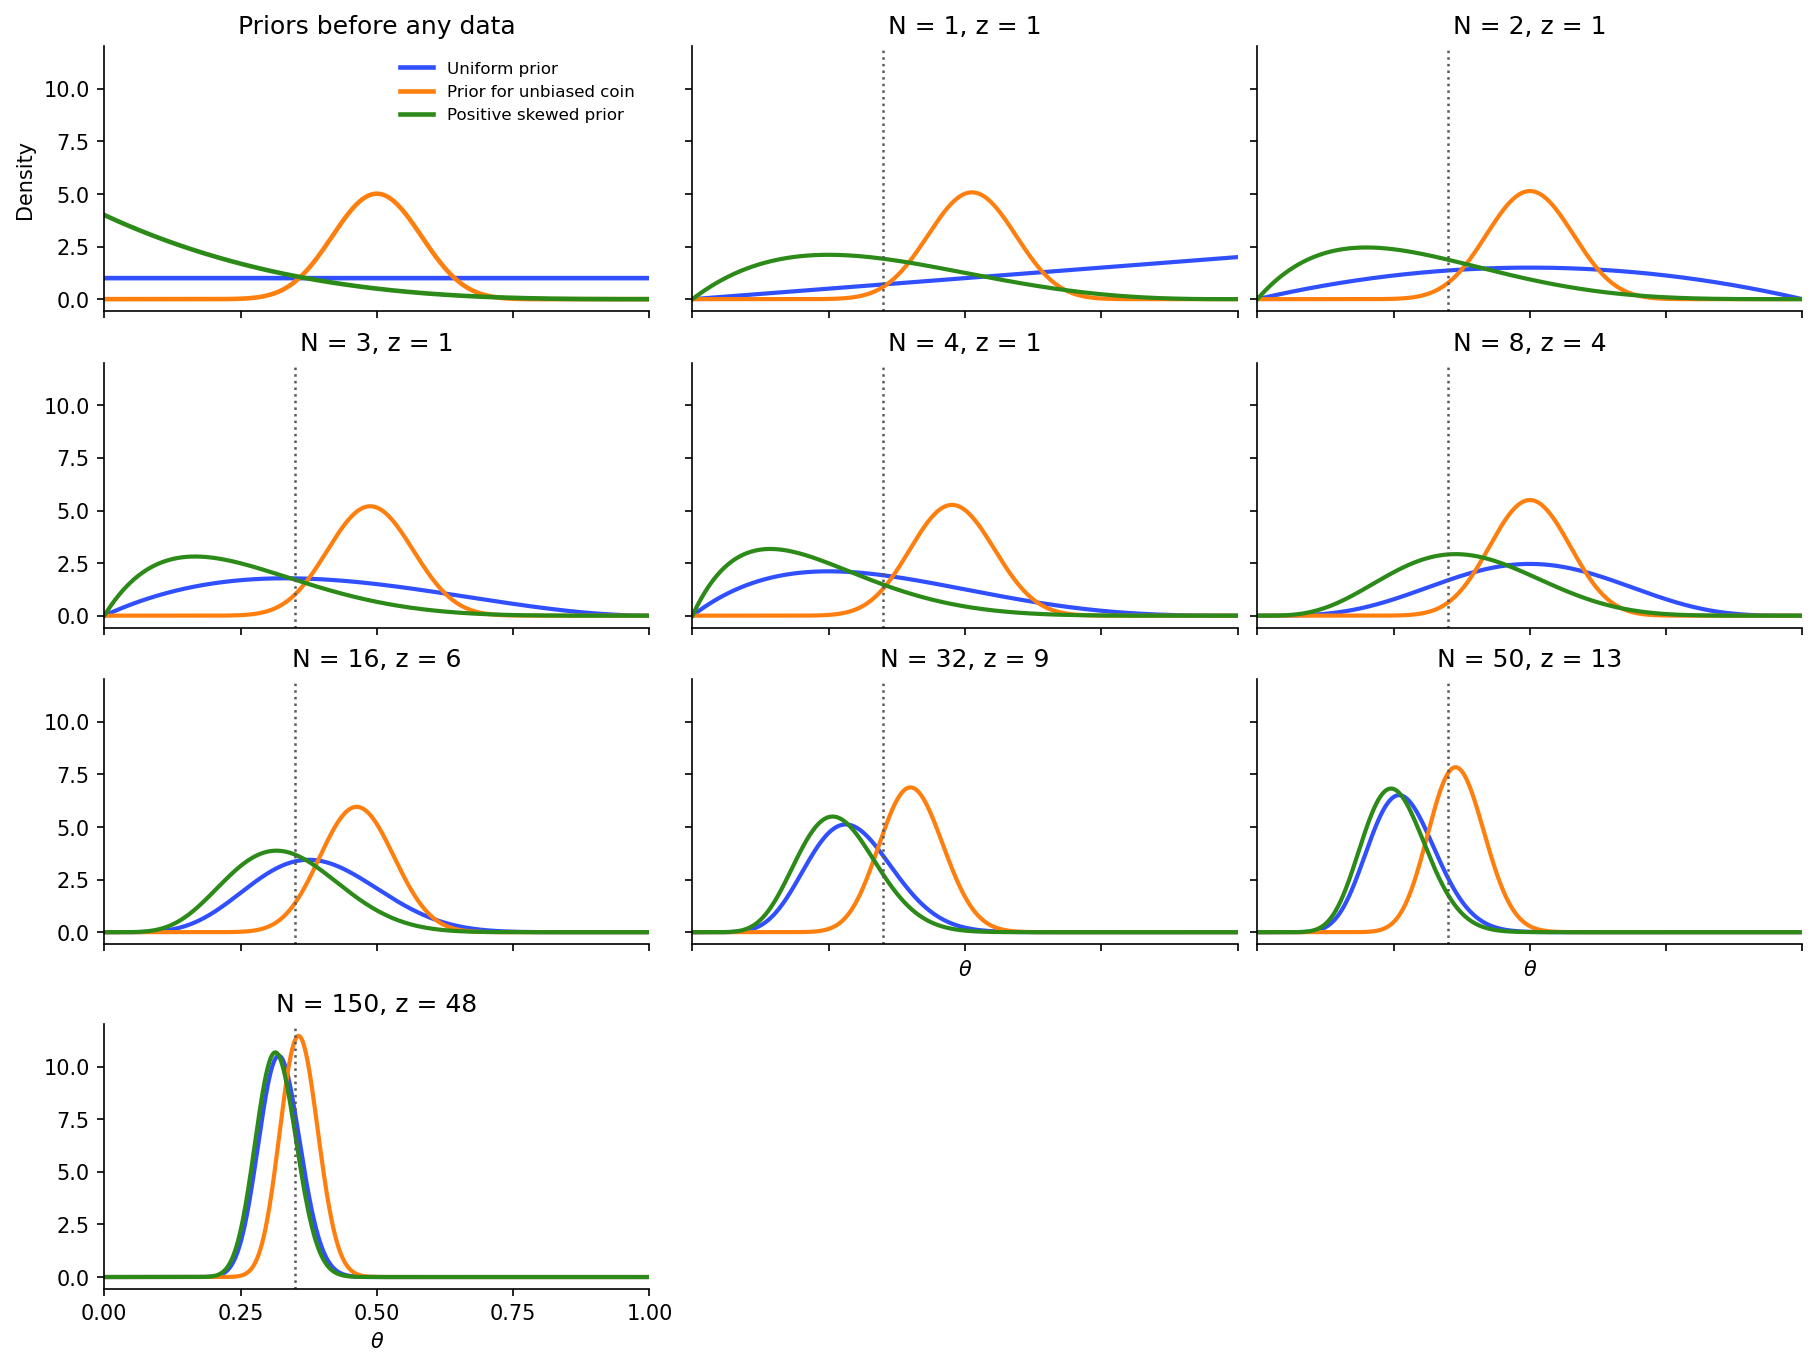

In [48]:
n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
n_heads = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
theta_real = 0.35

fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
axes_flat = axes.ravel()

for ax in axes_flat:
    ax.set_visible(False)

prior_ax = axes_flat[0]
prior_ax.set_visible(True)
for label, alpha, beta, color in PRIOR_SPECS:
    prior_ax.plot(THETA_GRID, beta_density(THETA_GRID, alpha, beta), color=color, linewidth=2.2, label=label)
prior_ax.set_title("Priors before any data")
format_theta_axis(prior_ax, ylabel="Density", xlabel=False)
prior_ax.legend(frameon=False, fontsize=8)

for ax, n, z in zip(axes_flat[1:10], n_trials[1:], n_heads[1:]):
    ax.set_visible(True)
    for _, alpha, beta, color in PRIOR_SPECS:
        posterior = posterior_density(THETA_GRID, alpha, beta, z, n)
        ax.plot(THETA_GRID, posterior, color=color, linewidth=2.0)
    ax.axvline(theta_real, color="0.35", linestyle=":", linewidth=1.2)
    ax.set_title(f"N = {n}, z = {z}")
    format_theta_axis(ax, ylabel=None, xlabel=False)

for ax in axes_flat[7:10]:
    ax.set_xlabel(r"$\theta$")

plt.show()


The order of the data does not matter for the final posterior. For the Beta-binomial
model, the update depends only on the total number of heads and the total number of
flips, not on the sequence in which those outcomes arrived.


<a id="section-210"></a>
## 2.10 Choosing priors
### Strong vs weak priors and elicitation mindset

Slides 62-65 discuss the practical question of prior strength and expert elicitation.
The figures below keep the data fixed (`z=1`, `N=4`) and show exactly how stronger or
weaker prior assumptions change the posterior.


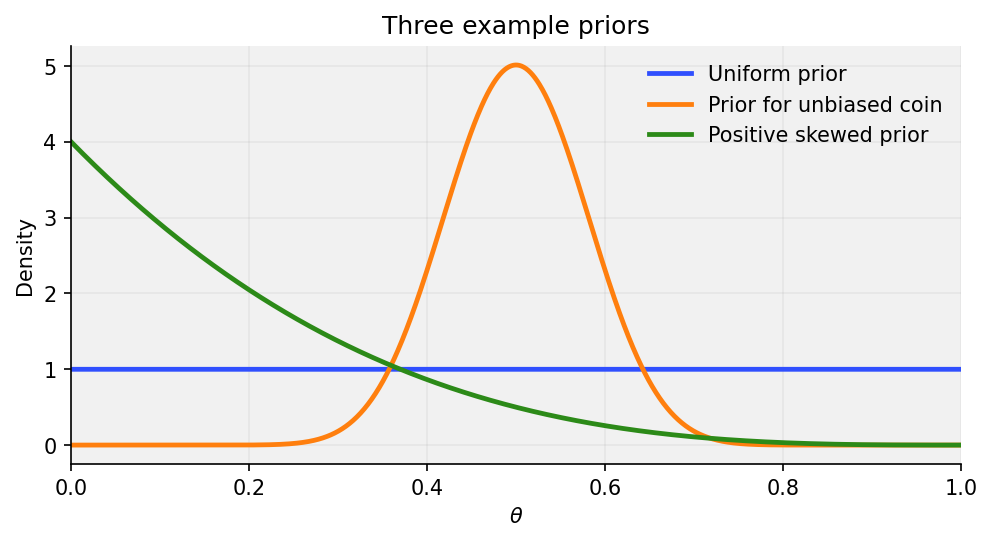

In [49]:
prior_sensitivity_z = 1
prior_sensitivity_n = 4

fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
for label, alpha, beta, color in PRIOR_SPECS:
    ax.plot(THETA_GRID, beta_density(THETA_GRID, alpha, beta), color=color, linewidth=2.3, label=label)
ax.set_facecolor(SLIDE_PANEL_FACE_COLOR)
ax.set_title("Three example priors")
ax.set_xlim(0, 1)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")
ax.grid(alpha=0.18)
ax.legend(frameon=False)
plt.show()


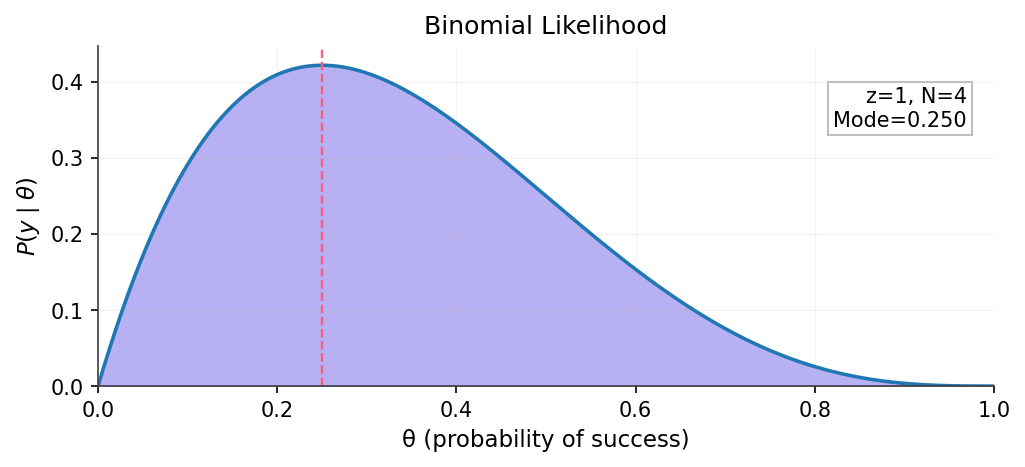

In [50]:
plot_slide_distribution(
    THETA_GRID,
    binomial_likelihood(THETA_GRID, prior_sensitivity_z, prior_sensitivity_n),
    title="Binomial Likelihood",
    ylabel=r"$P(y \mid \theta)$",
    line_color=SLIDE_LIKELIHOOD_LINE_COLOR,
    fill_color=SLIDE_LIKELIHOOD_FILL_COLOR,
    box_lines=[f"z={prior_sensitivity_z}, N={prior_sensitivity_n}"],
    show_mode=True,
)


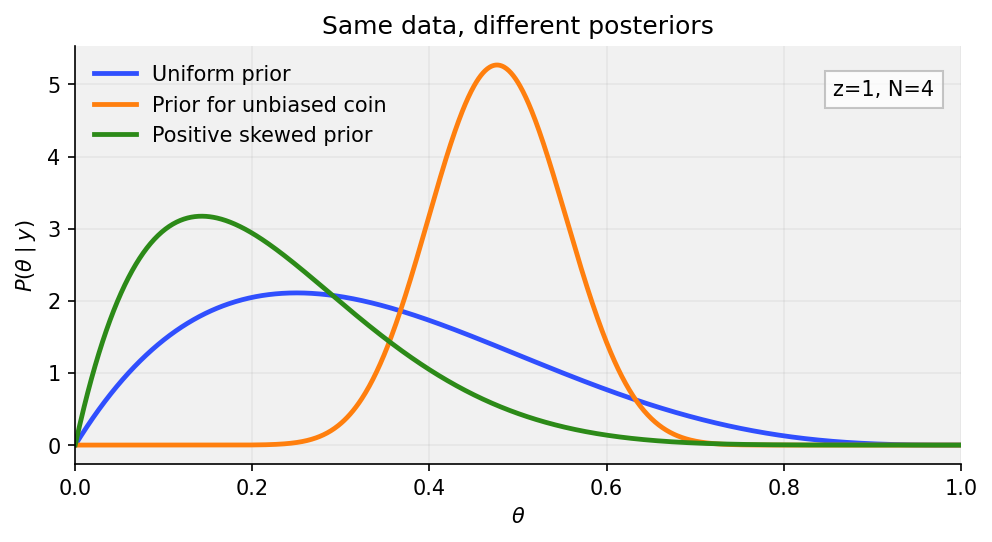

In [51]:
fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
for label, alpha, beta, color in PRIOR_SPECS:
    posterior = posterior_from_product(THETA_GRID, alpha, beta, prior_sensitivity_z, prior_sensitivity_n)
    ax.plot(THETA_GRID, posterior, color=color, linewidth=2.3, label=label)
ax.set_facecolor(SLIDE_PANEL_FACE_COLOR)
ax.set_title("Same data, different posteriors")
ax.set_xlim(0, 1)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$P(\theta \mid y)$")
ax.grid(alpha=0.18)
ax.text(
    0.97,
    0.92,
    f"z={prior_sensitivity_z}, N={prior_sensitivity_n}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "0.7"},
)
ax.legend(frameon=False)
plt.show()


<a id="section-211"></a>
## 2.11 Preliz
### Prior elicitation with `pz.maxent`

Slides 66-69 introduce `Preliz` as a prior-elicitation tool. The lecture example says:
"I am pretty sure the coin's probability is somewhere between 0.1 and 0.7."

The code below asks `Preliz` for a Beta prior with 90% of its mass between those bounds.


Elicited prior: Beta(alpha=2.475, beta=3.610) with 90% mass between 0.1 and 0.7


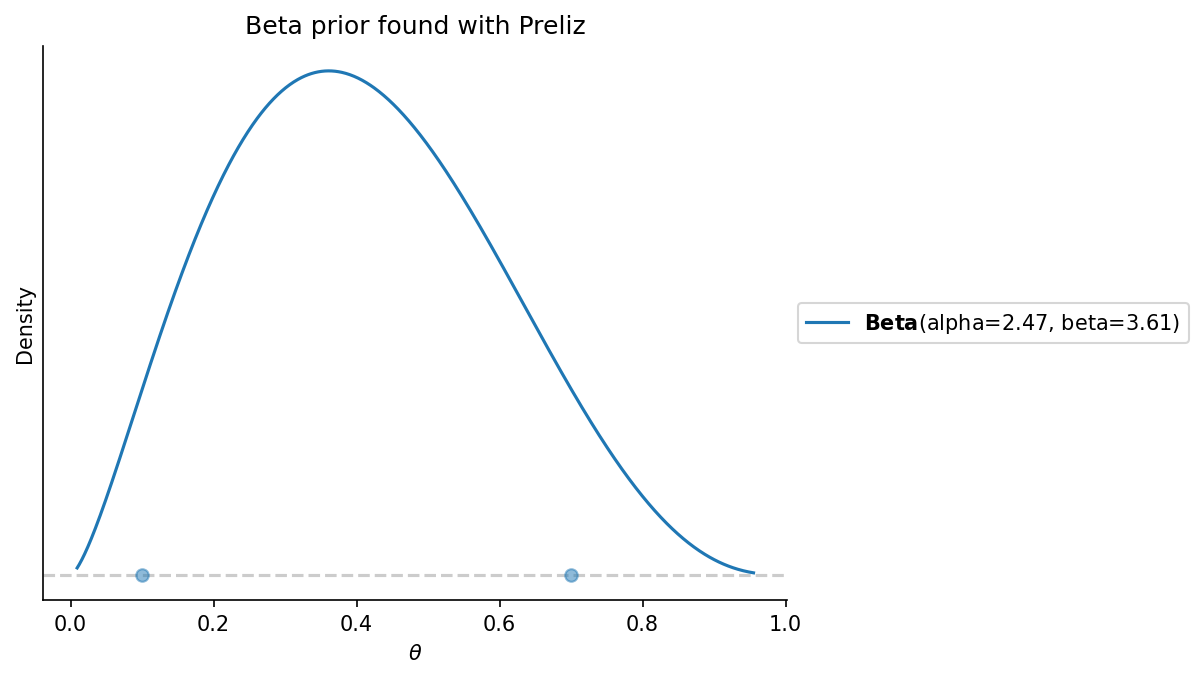

In [52]:
try:
    import preliz as pz
except ImportError as exc:
    if IS_COLAB:
        ensure_package("preliz")
        import preliz as pz
    else:
        raise ImportError(
            "Section 2.11 requires the `preliz` package. Install it locally or run this notebook in Colab."
        ) from exc

elicited_lower = 0.10
elicited_upper = 0.70
elicited_mass = 0.90

elicited_prior, ax = pz.maxent(
    pz.Beta(),
    lower=elicited_lower,
    upper=elicited_upper,
    mass=elicited_mass,
    plot=True,
)

elicited_alpha = elicited_prior.alpha
elicited_beta = elicited_prior.beta

ax.set_title("Beta prior found with Preliz")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Density")

print(
    "Elicited prior: "
    f"Beta(alpha={elicited_alpha:.3f}, beta={elicited_beta:.3f}) "
    f"with {elicited_mass:.0%} mass between {elicited_lower:.1f} and {elicited_upper:.1f}"
)


<a id="section-212"></a>
## 2.12 Next week
### Why we move from grids to sampling

Slides 70-72 explain why full-grid calculations do not scale to high-dimensional
parameter spaces and motivate sampling methods (the focus of the next lecture).
